In [1]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.scorematching_penalized import *
from dekef.scorematching_earlystopping import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]
# waiting = np.append(waiting, contam_pt)

bw = 5.
kernel_type = 'gaussian_poly2'

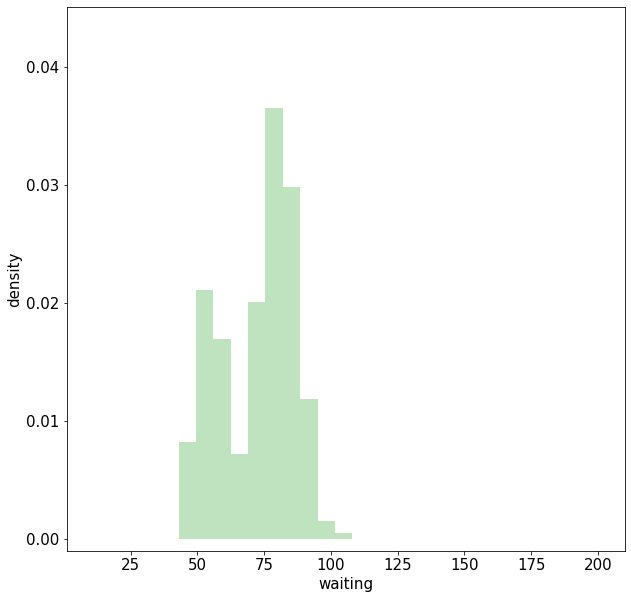

In [3]:
# set plot parameters
font_size = 15
xlimit = (1., 210.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
108 in waiting

True

In [5]:
base_density = BasedenGamma(waiting, 36., 2.)
base_density.a, base_density.scale

(36.0, 2.0)

## Penalized approach

In [6]:
sm_pen = ScoreMatchingPenalized(
    data = waiting, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

In [7]:
plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

sm_folder = (f'../data/data=geyser-waiting-PenSM-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'entire-RKHS')

if not os.path.isdir(sm_folder):
    os.mkdir(sm_folder)

file_name_newdata = f'/new_data.npy'
np.save(sm_folder + file_name_newdata, new_data)

**************************************************
log penalty = -15.0


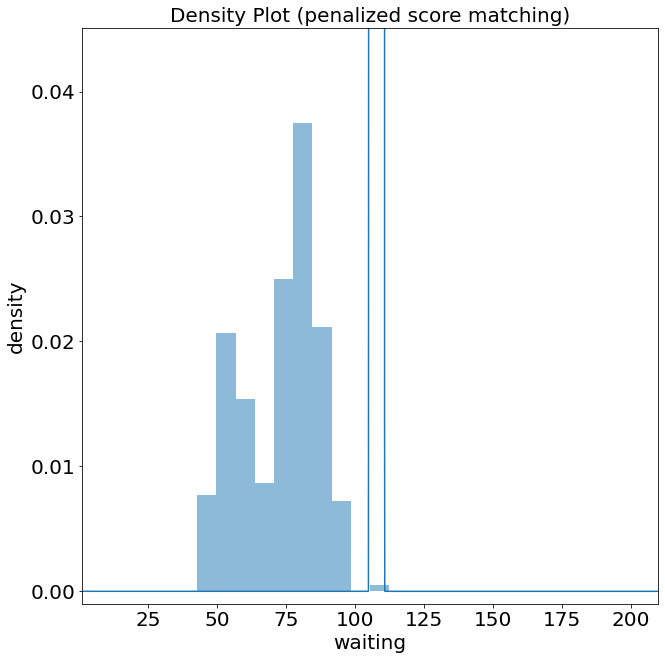

**************************************************
log penalty = -14.5


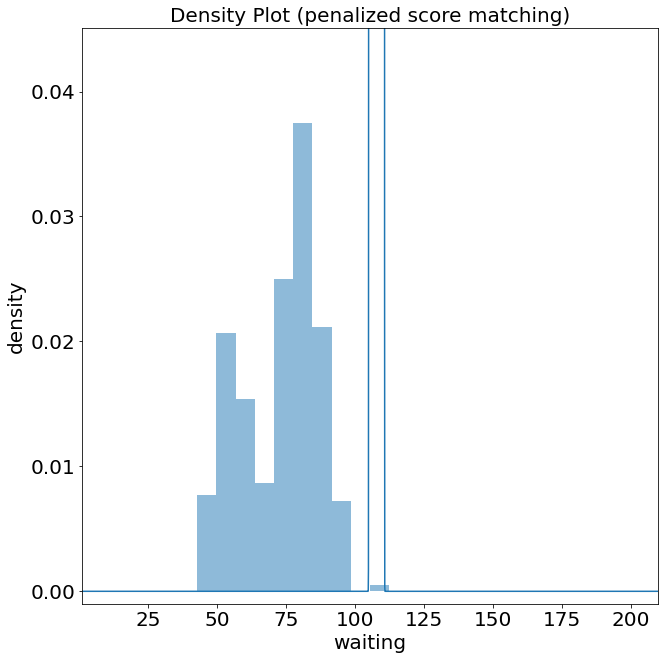

**************************************************
log penalty = -14.0


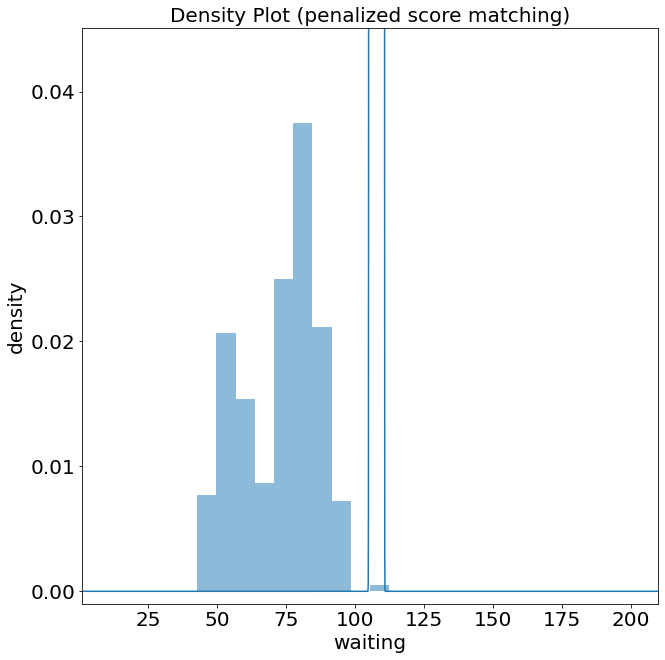

**************************************************
log penalty = -13.5


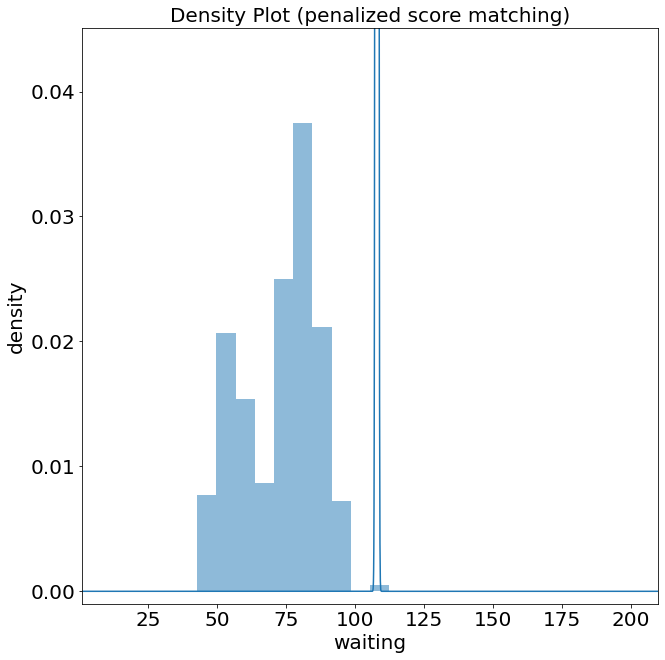

**************************************************
log penalty = -13.0


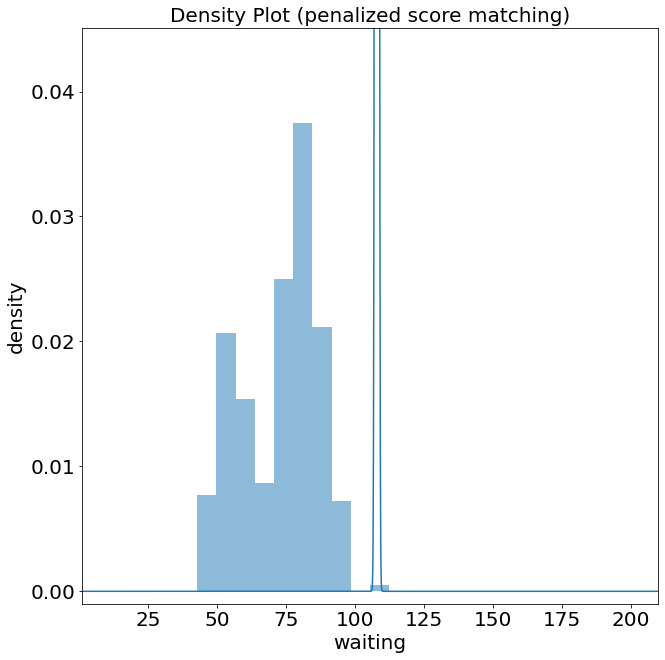

**************************************************
log penalty = -12.5


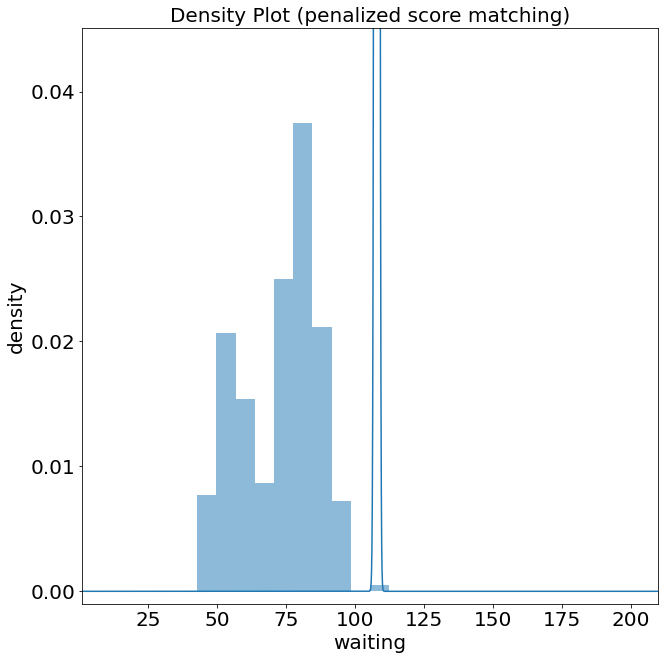

**************************************************
log penalty = -12.0


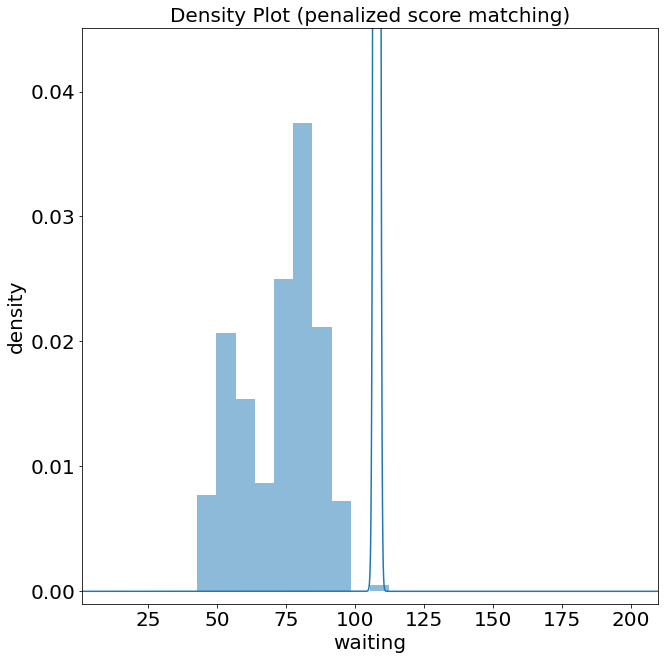

**************************************************
log penalty = -11.5


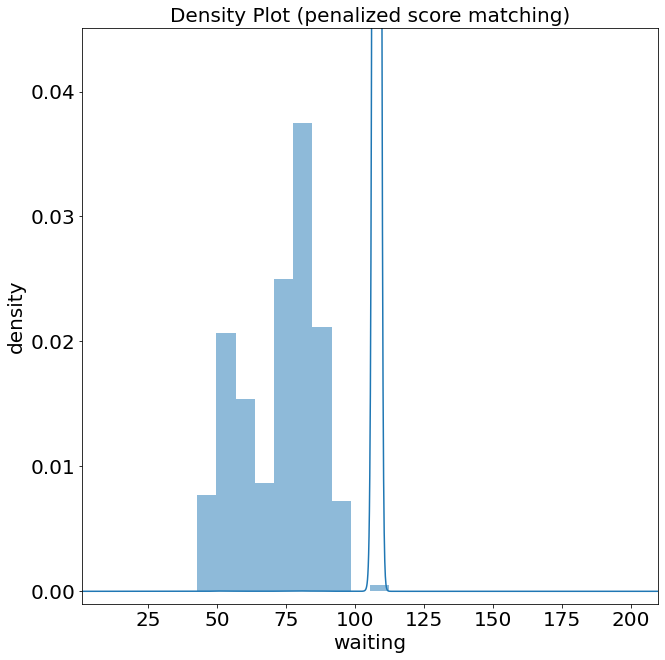

**************************************************
log penalty = -11.0


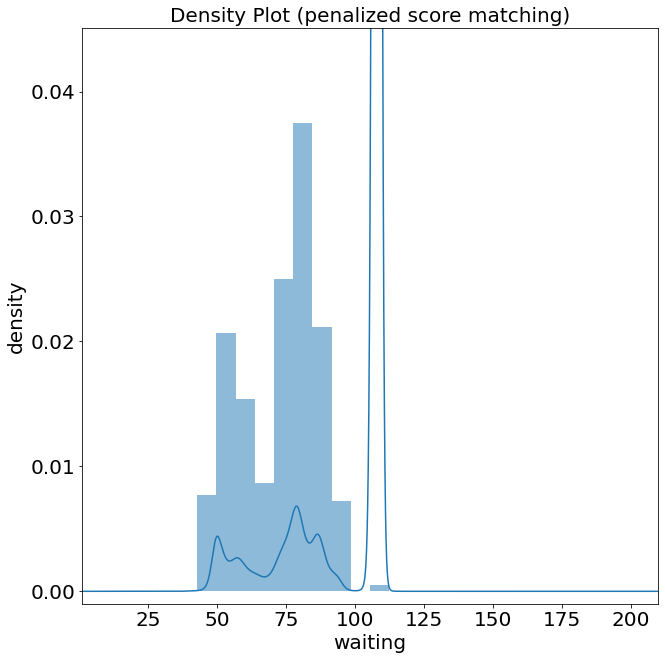

**************************************************
log penalty = -10.5


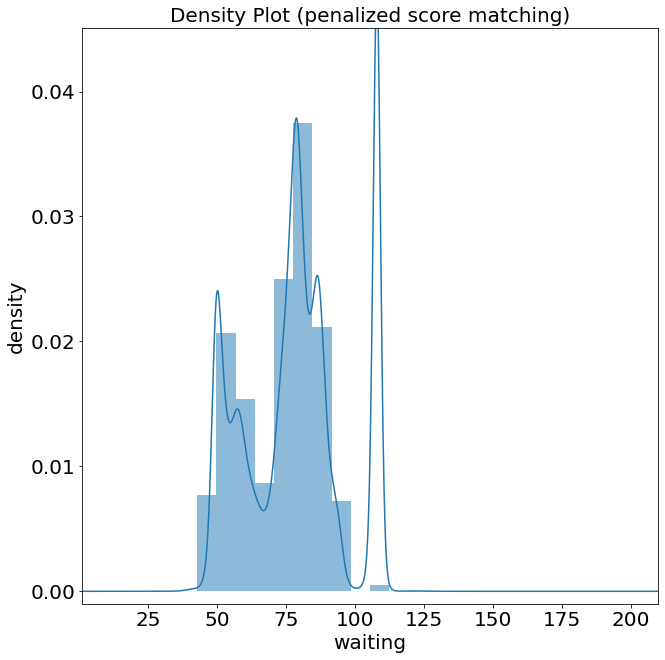

**************************************************
log penalty = -10.0


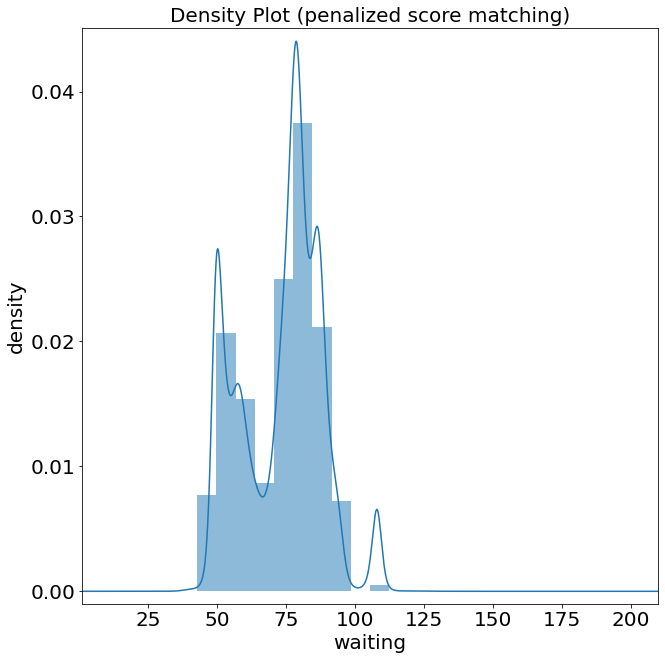

**************************************************
log penalty = -9.5


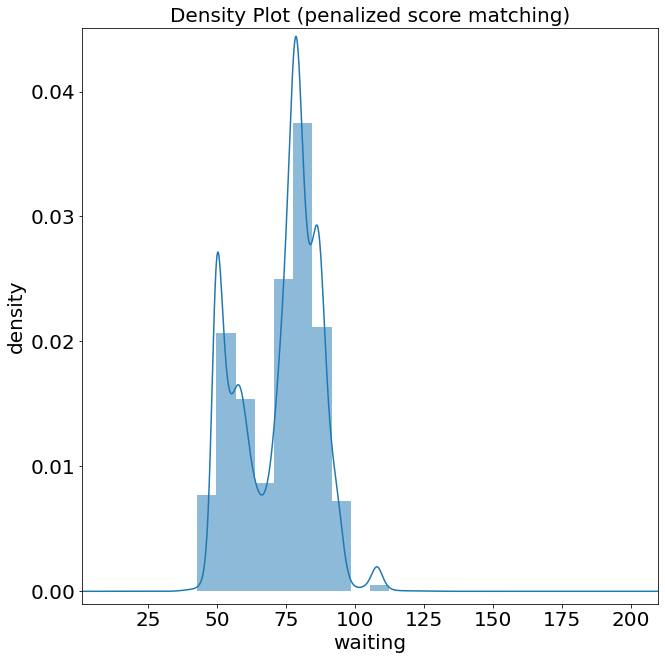

**************************************************
log penalty = -9.0


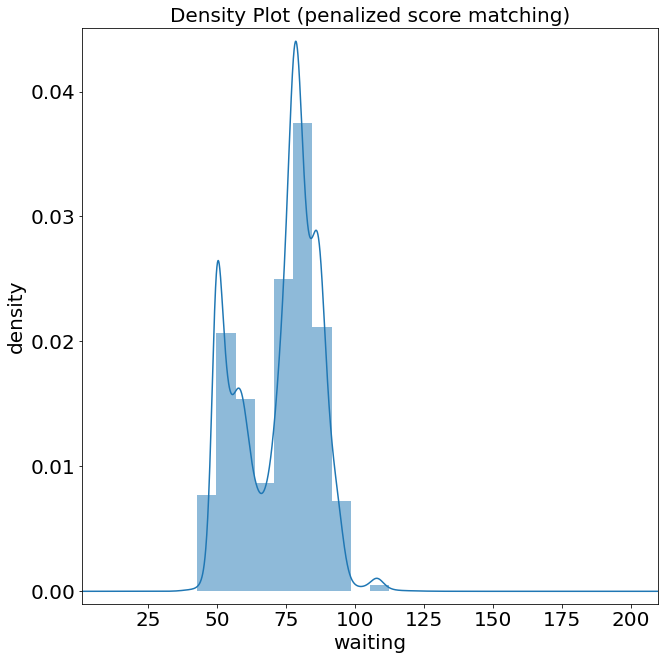

**************************************************
log penalty = -8.5


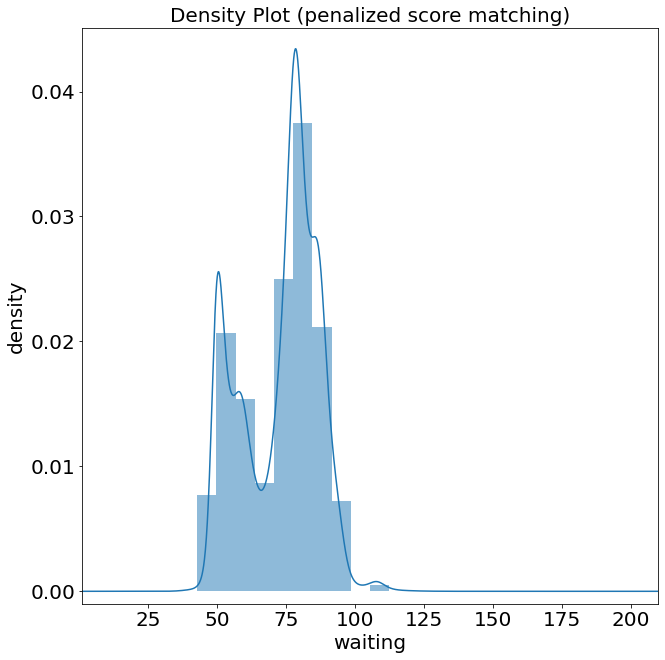

**************************************************
log penalty = -8.0


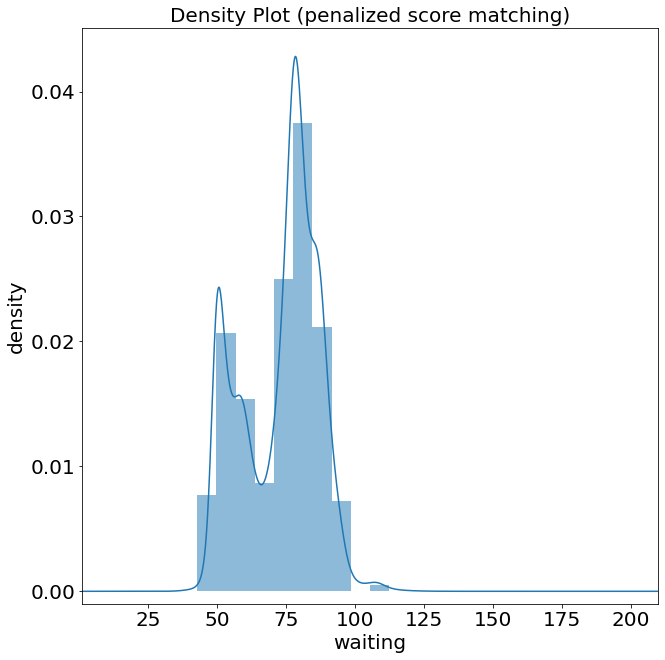

**************************************************
log penalty = -7.5


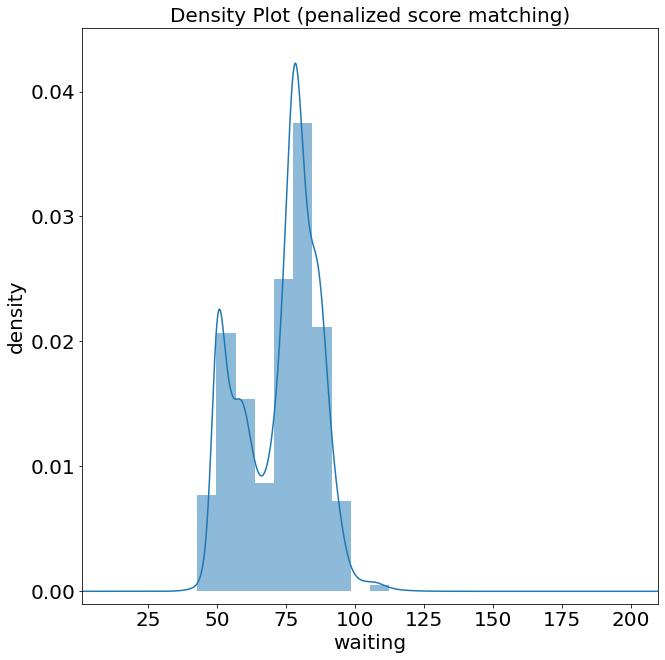

**************************************************
log penalty = -7.0


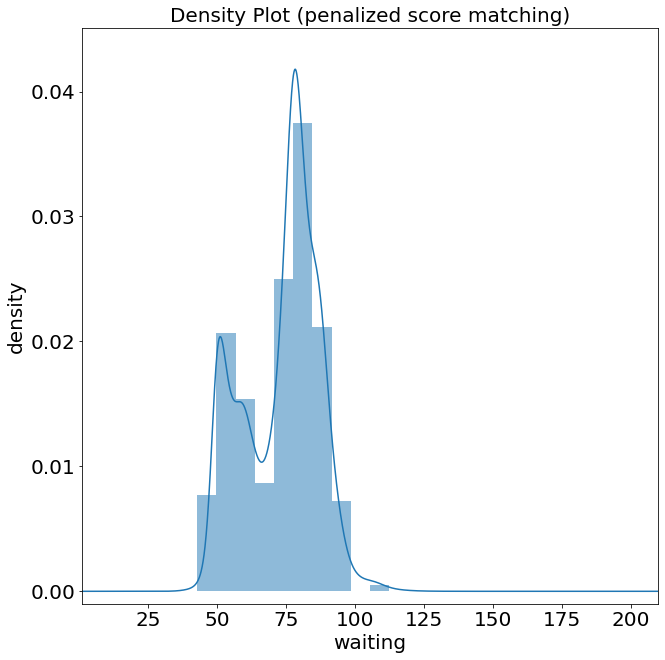

**************************************************
log penalty = -6.5


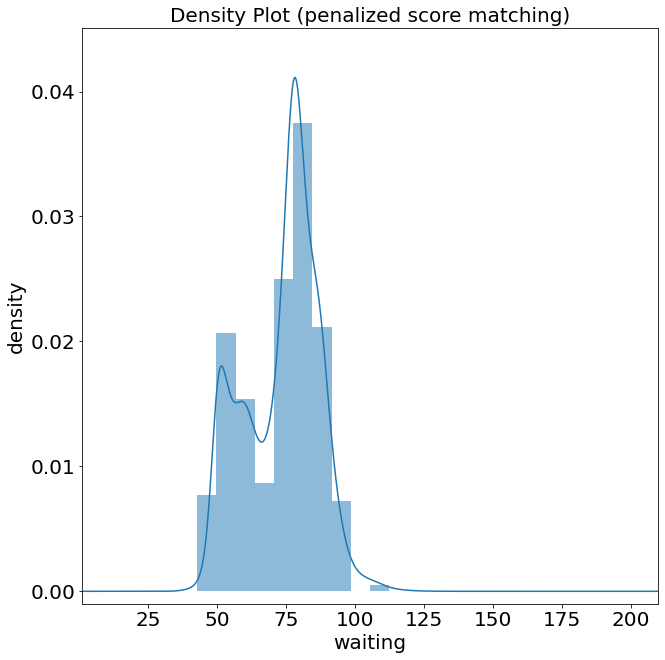

**************************************************
log penalty = -6.0


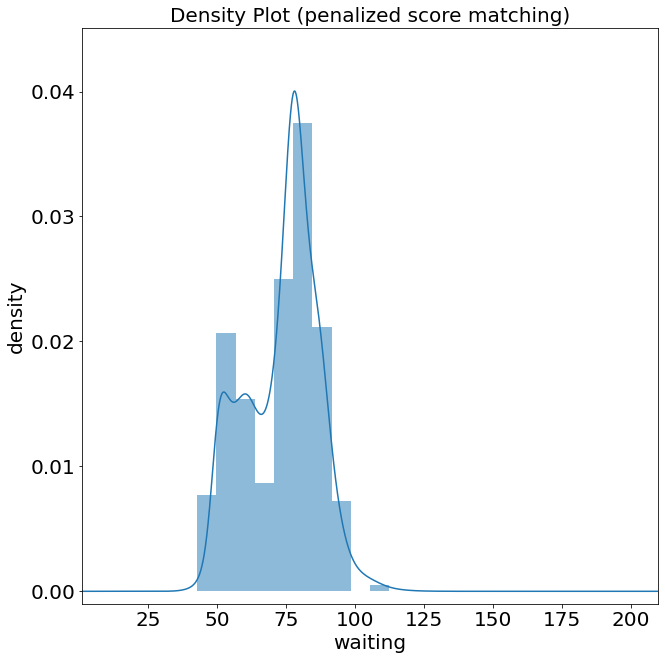

**************************************************
log penalty = -5.5


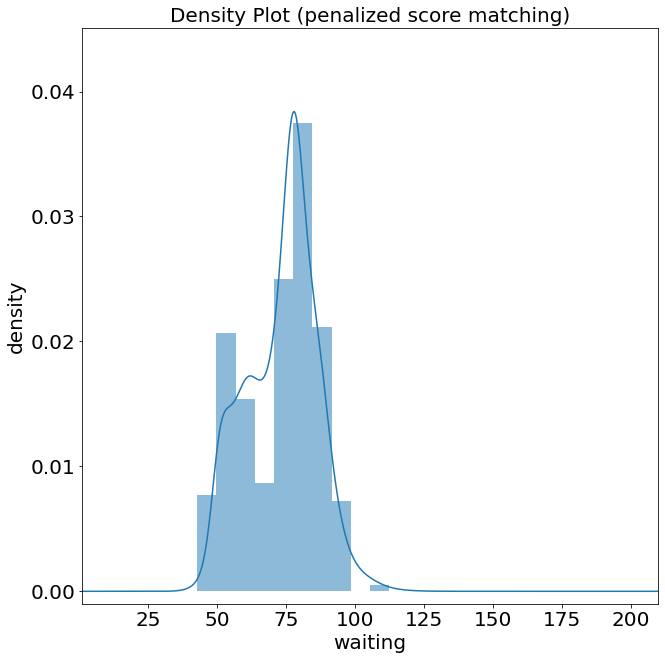

**************************************************
log penalty = -5.0


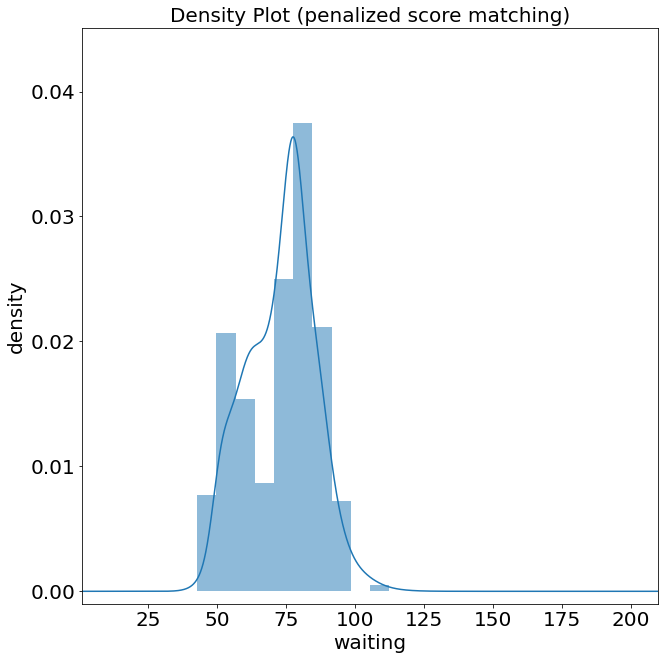

**************************************************
log penalty = -4.5


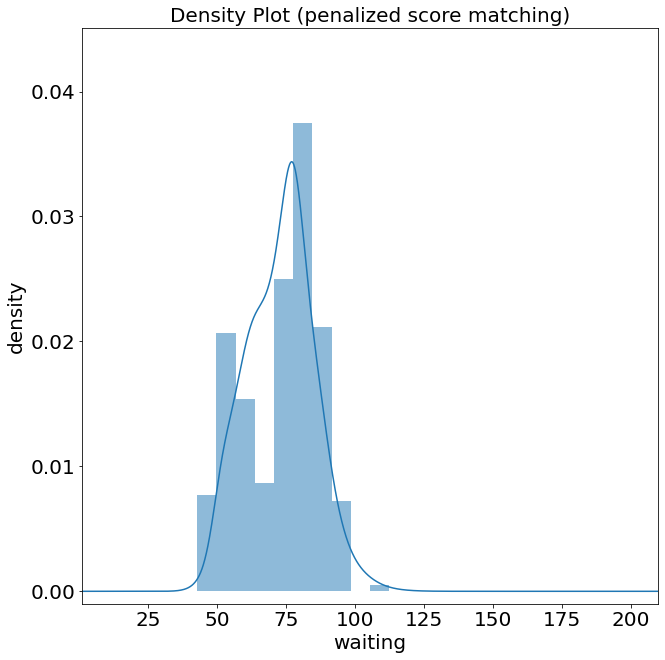

**************************************************
log penalty = -4.0


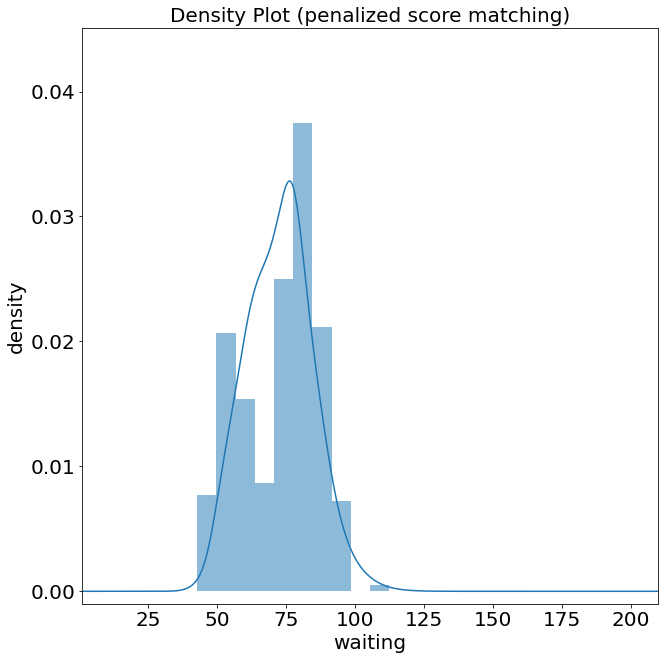

**************************************************
log penalty = -3.5


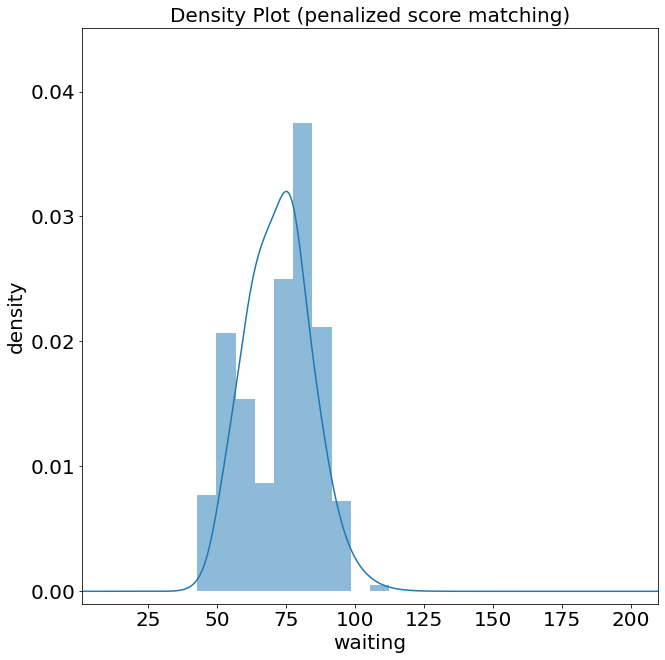

**************************************************
log penalty = -3.0


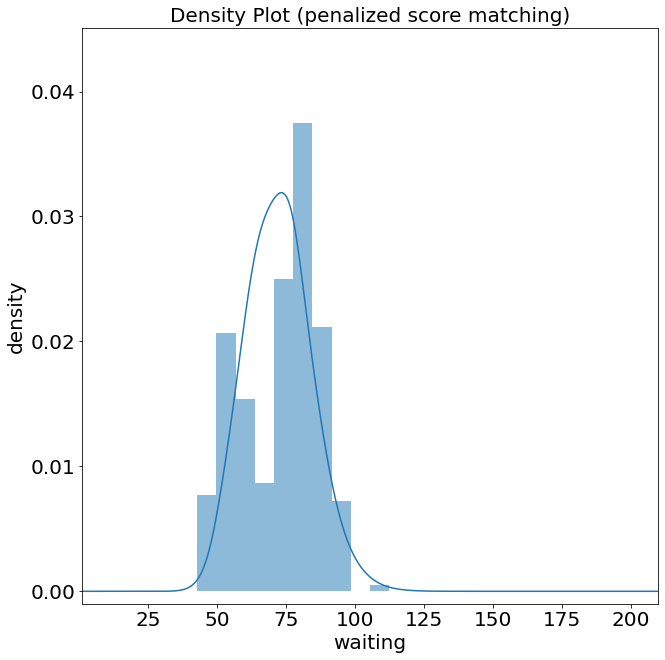

**************************************************
log penalty = -2.5


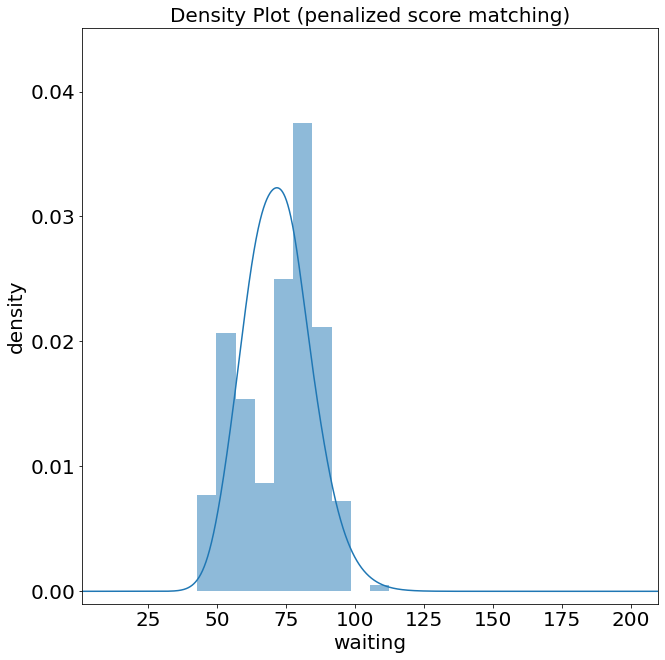

**************************************************
log penalty = -2.0


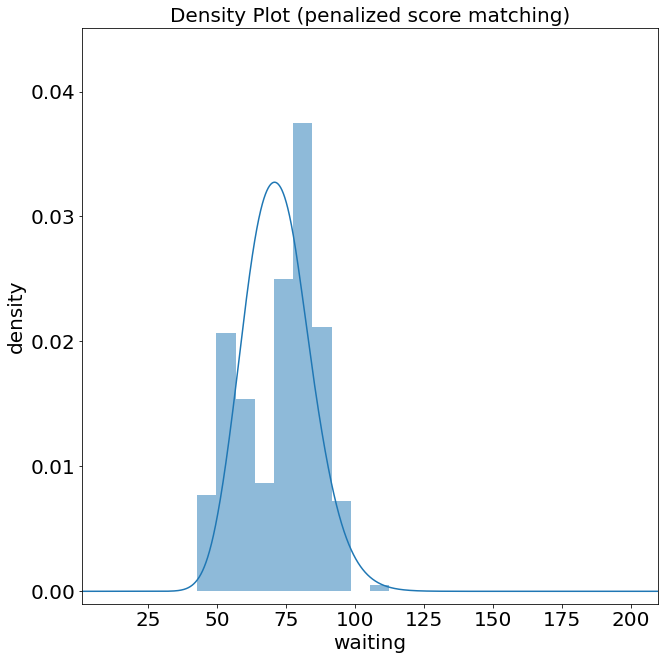

**************************************************
log penalty = -1.5


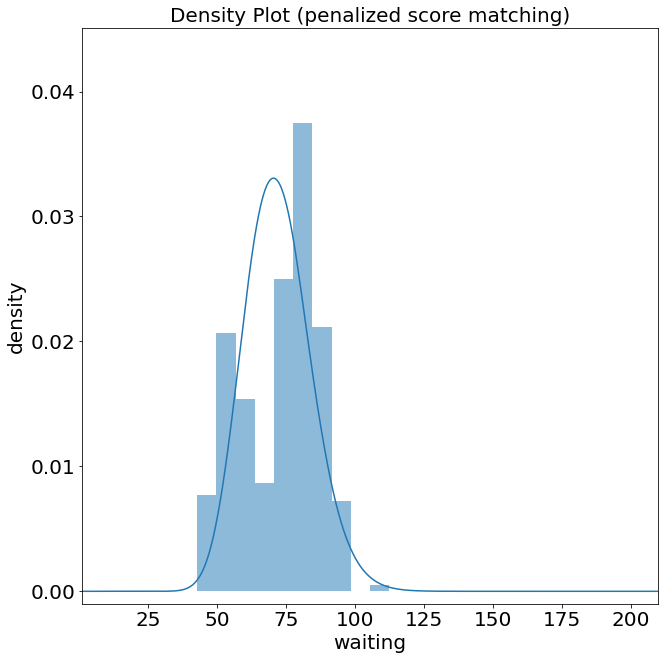

**************************************************
log penalty = -1.0


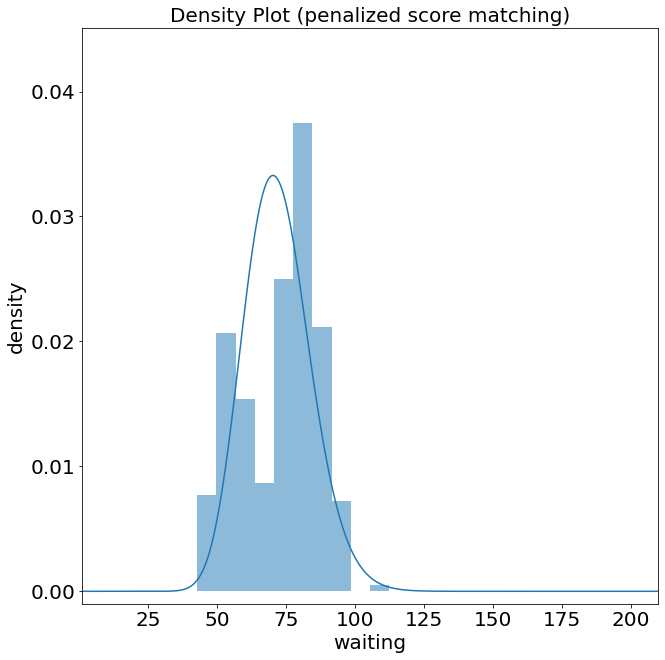

**************************************************
log penalty = -0.5


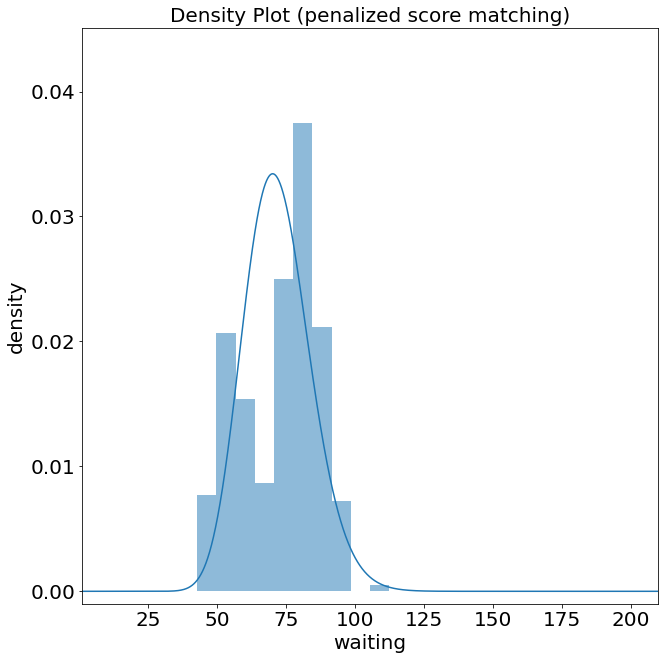

**************************************************
log penalty = 0.0


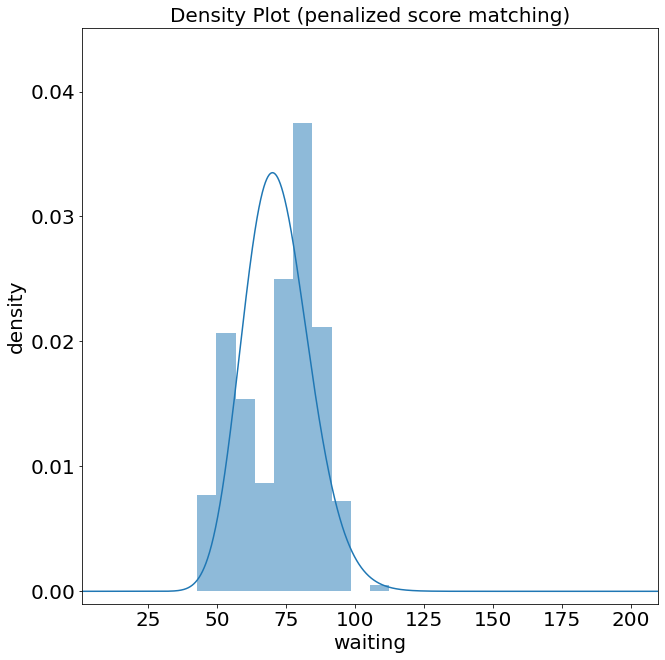

**************************************************
log penalty = 0.5


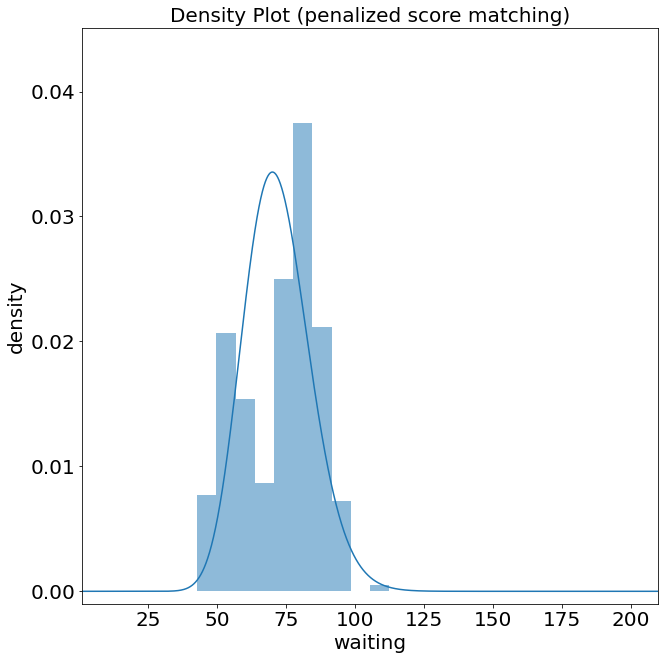

**************************************************
log penalty = 1.0


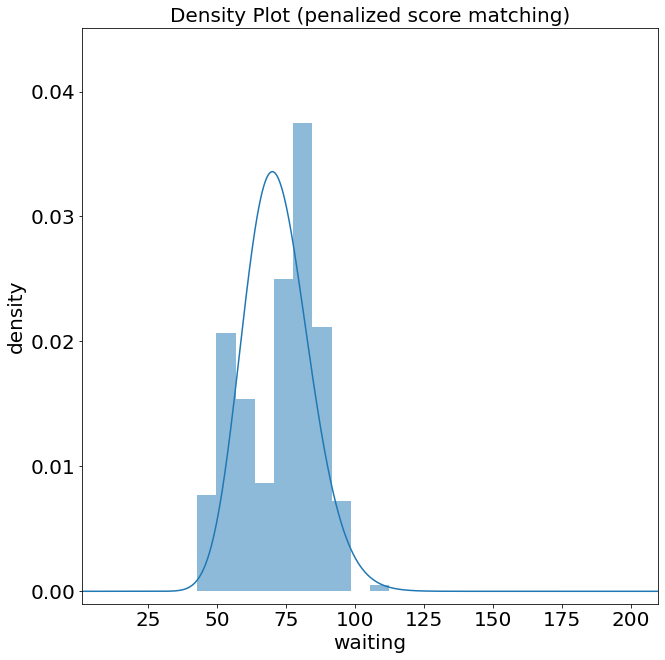

In [8]:
log_penalty_param_list = np.arange(-15., 1.5, 0.5)

for log_pen_param in log_penalty_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    coef_smpen = sm_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param))
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'smbasis', 
        coef = coef_smpen, 
        normalizing = True, 
        method = 'penalized score matching', 
        x_label = 'waiting',
        grid_points = None,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(sm_folder + file_name_coef, coef_smpen)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(sm_folder + file_name_den, den_vals['den_vals'])
    

## Early Stopping 

In [6]:
sm_es = ScoreMatchingEarlyStopping(
    data = waiting, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw)

In [7]:
plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

sm_folder = (f'../data/data=geyser-waiting-EarlyStoppingSM-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'entire-RKHS')

# if not os.path.isdir(sm_folder):
#     os.mkdir(sm_folder)

file_name_newdata = f'/new_data.npy'
np.save(sm_folder + file_name_newdata, new_data)

**************************************************
iter number = 100000


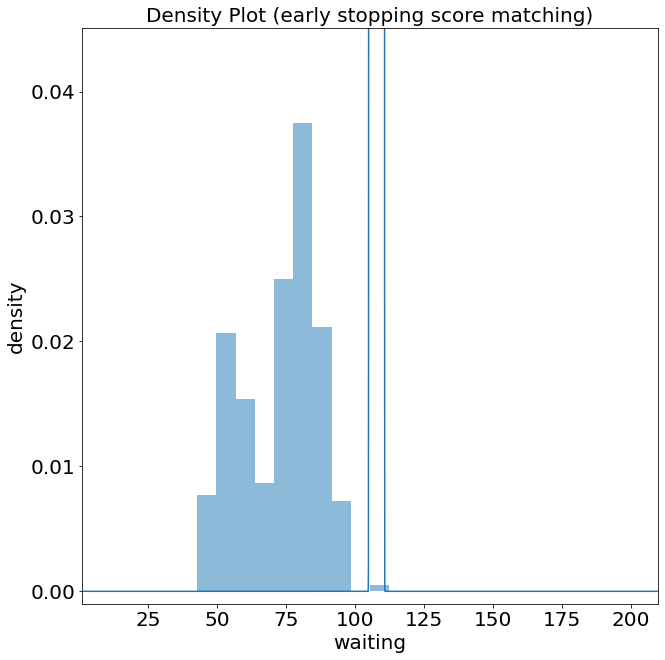

**************************************************
iter number = 90000


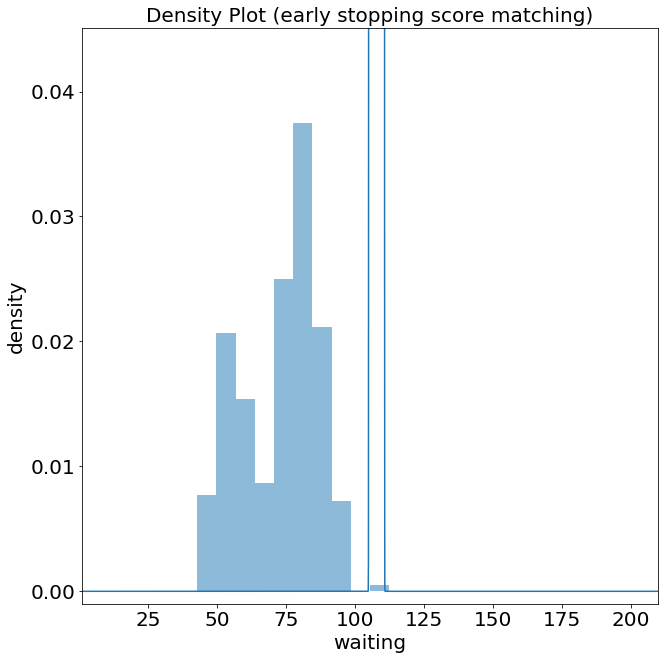

**************************************************
iter number = 80000


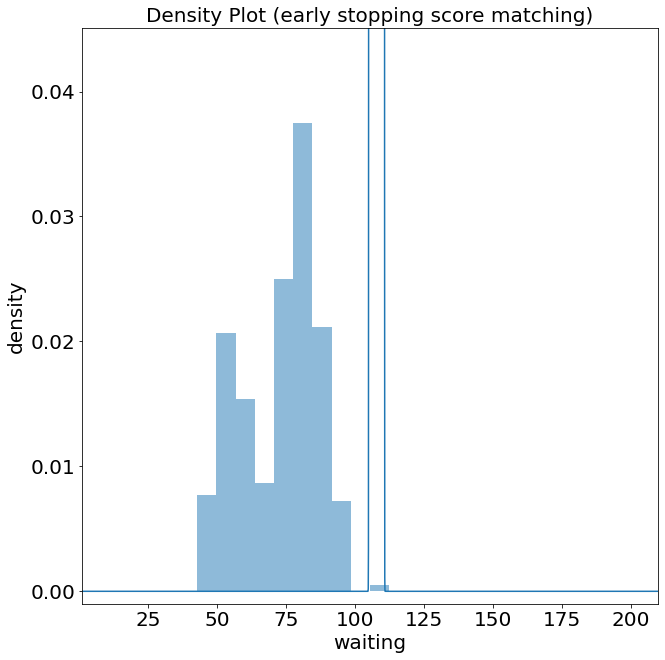

**************************************************
iter number = 70000


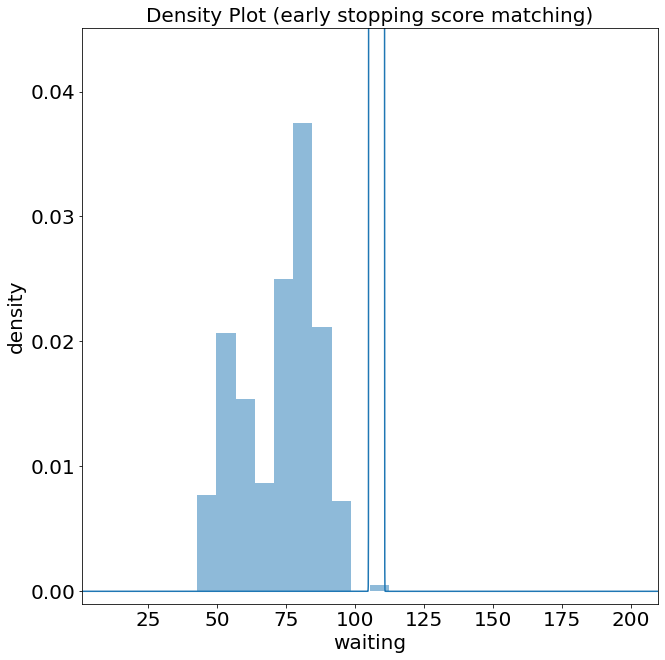

**************************************************
iter number = 60000


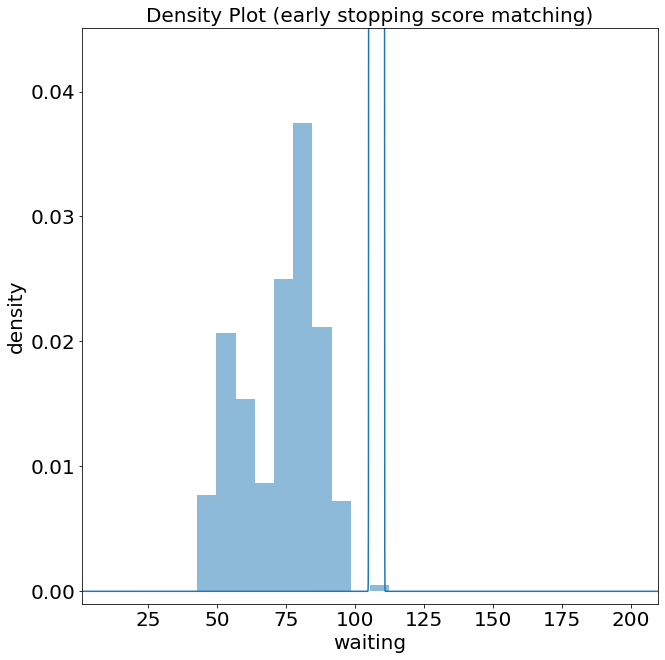

**************************************************
iter number = 50000


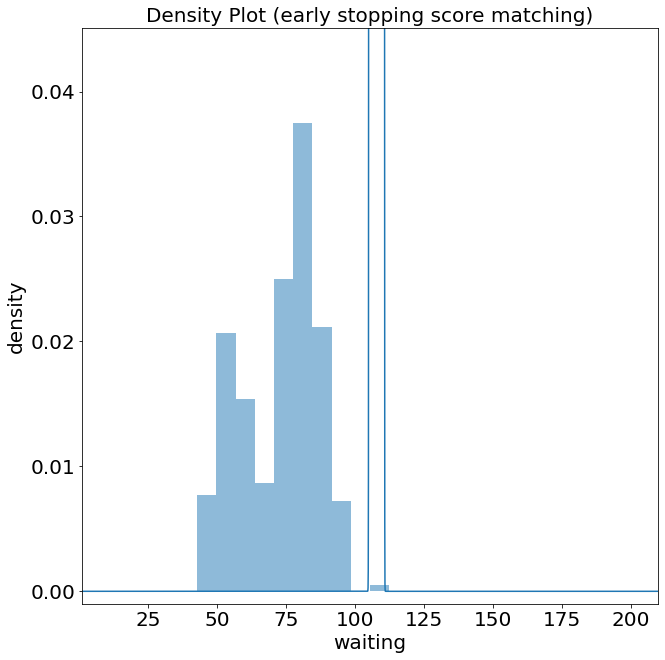

**************************************************
iter number = 40000


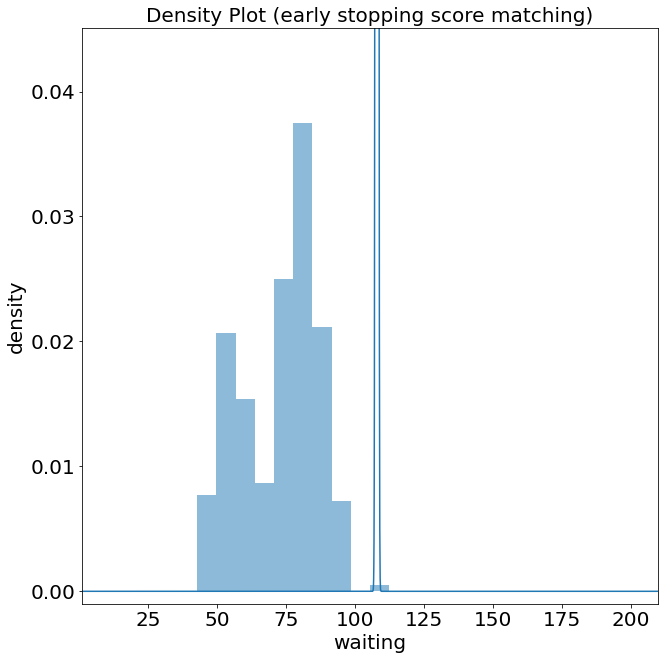

**************************************************
iter number = 30000


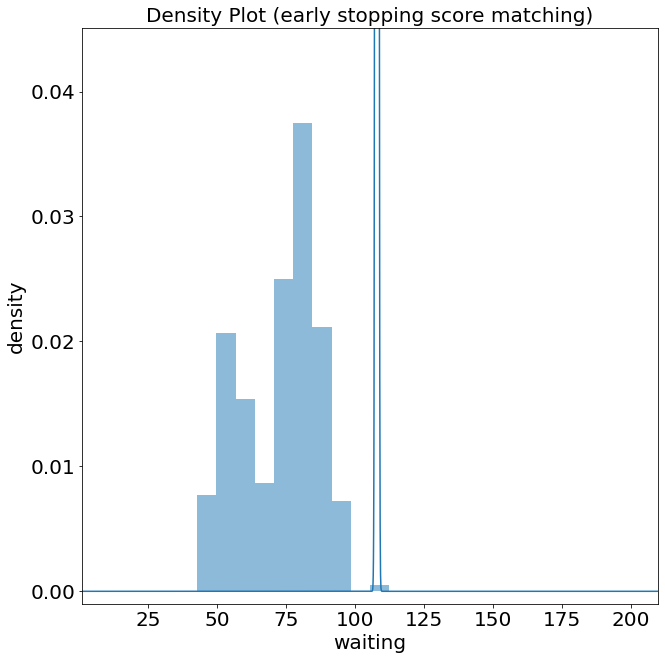

**************************************************
iter number = 20000


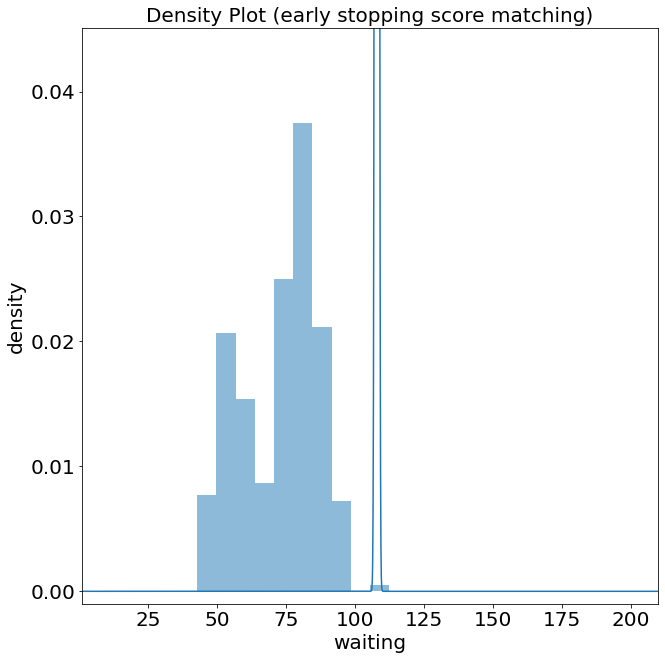

**************************************************
iter number = 10000


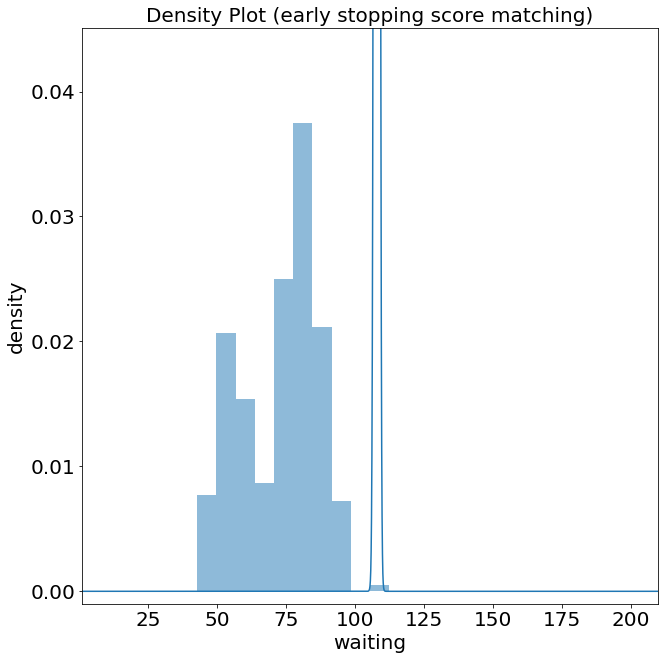

**************************************************
iter number = 9000


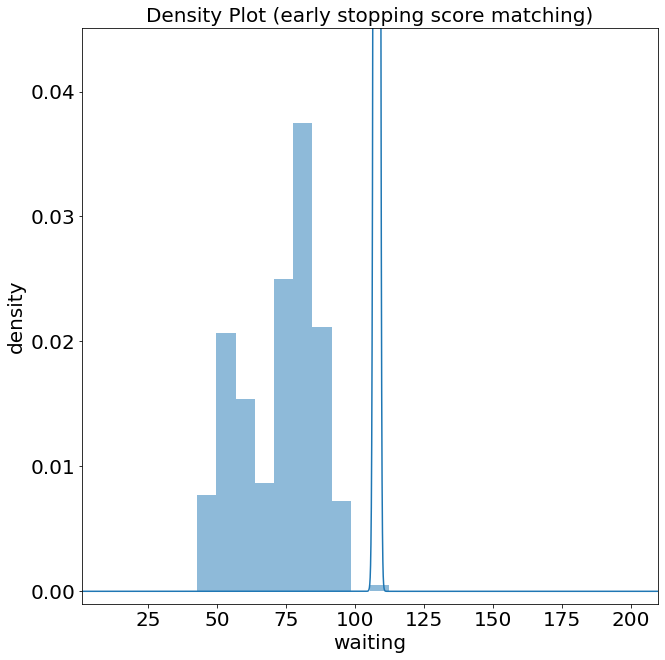

**************************************************
iter number = 8000


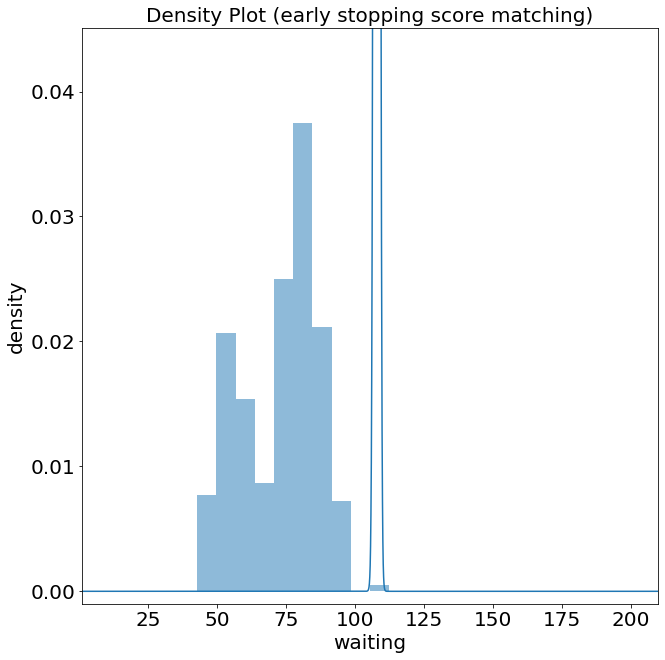

**************************************************
iter number = 7000


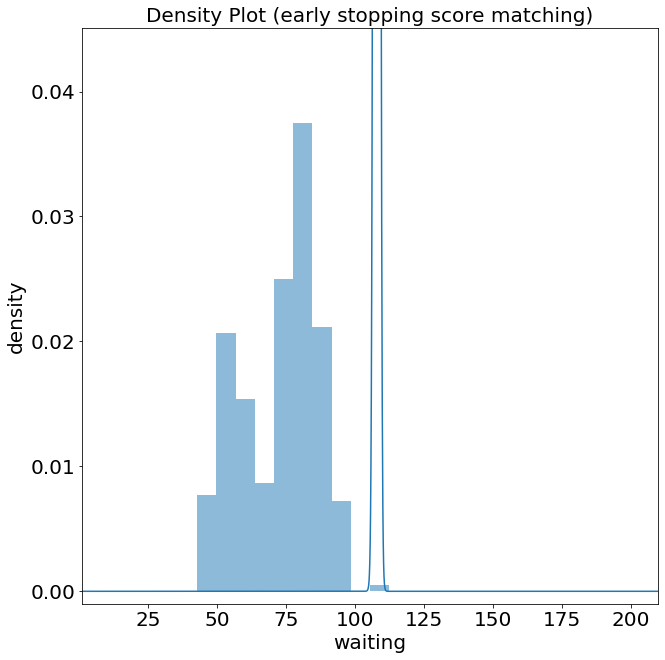

**************************************************
iter number = 6000


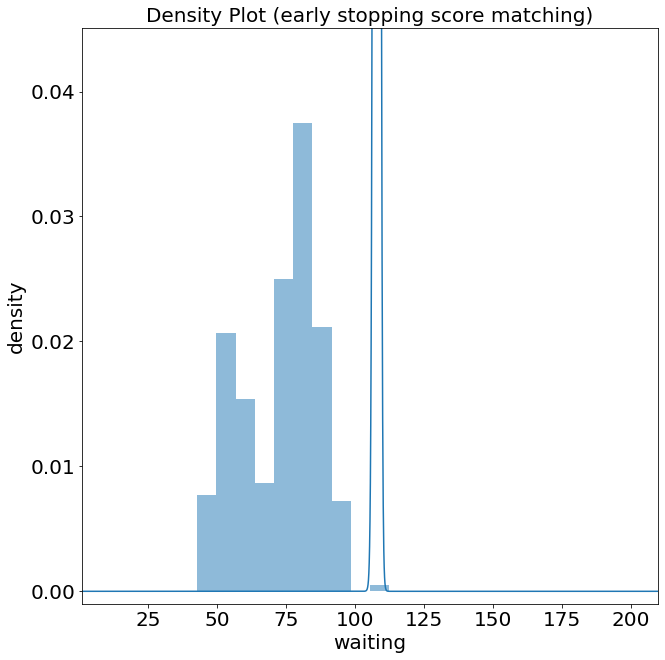

**************************************************
iter number = 5000


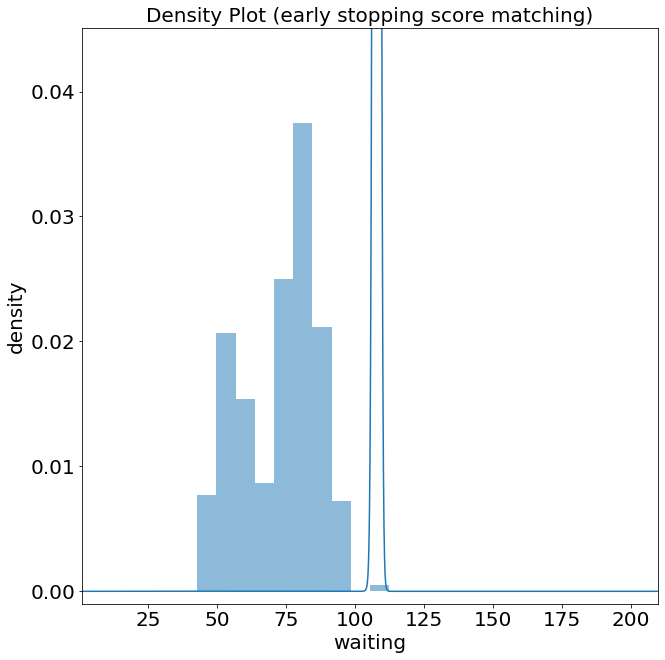

**************************************************
iter number = 4000


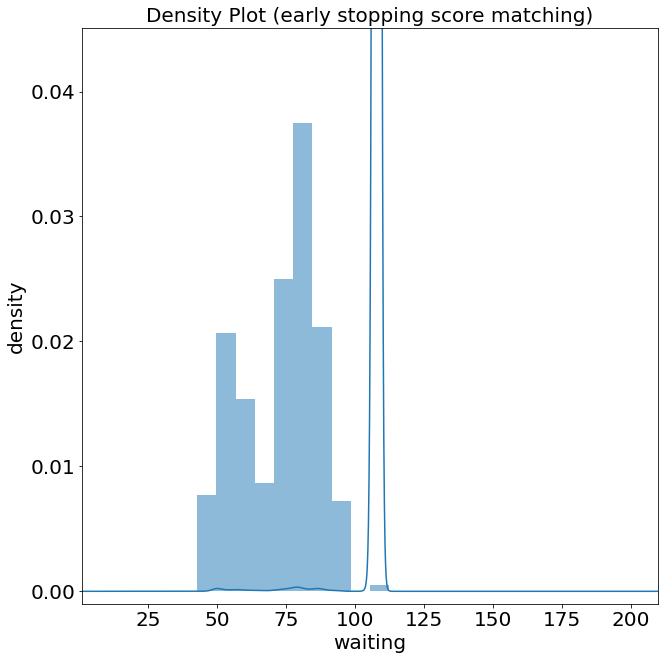

**************************************************
iter number = 3000


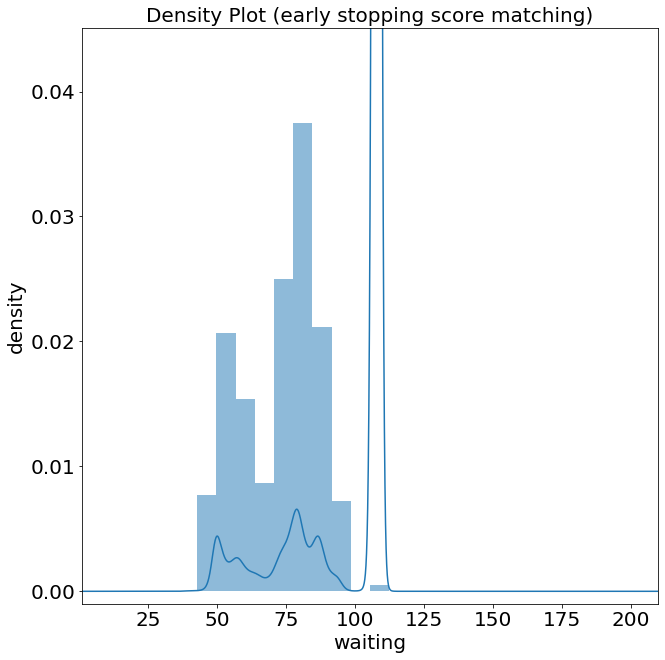

**************************************************
iter number = 2000


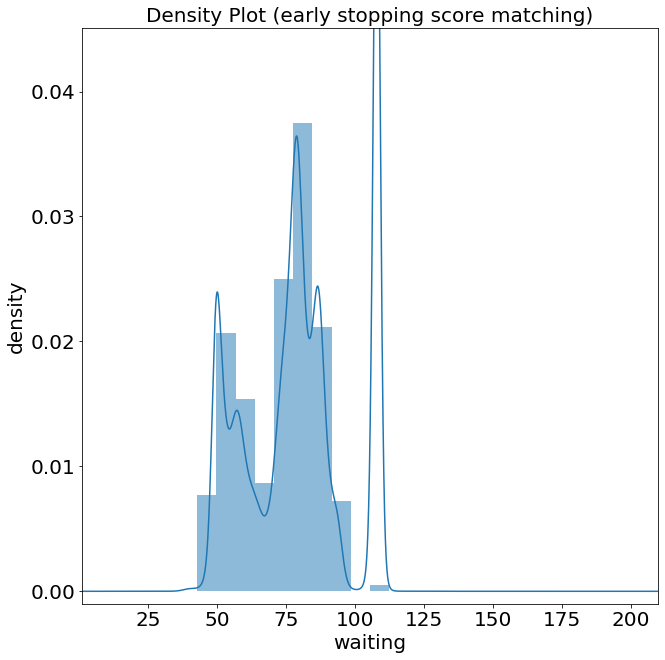

**************************************************
iter number = 1500


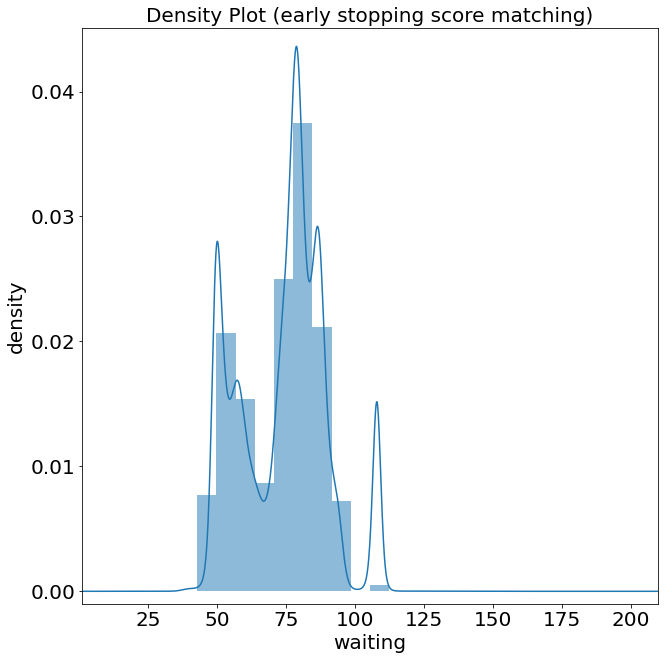

**************************************************
iter number = 1000


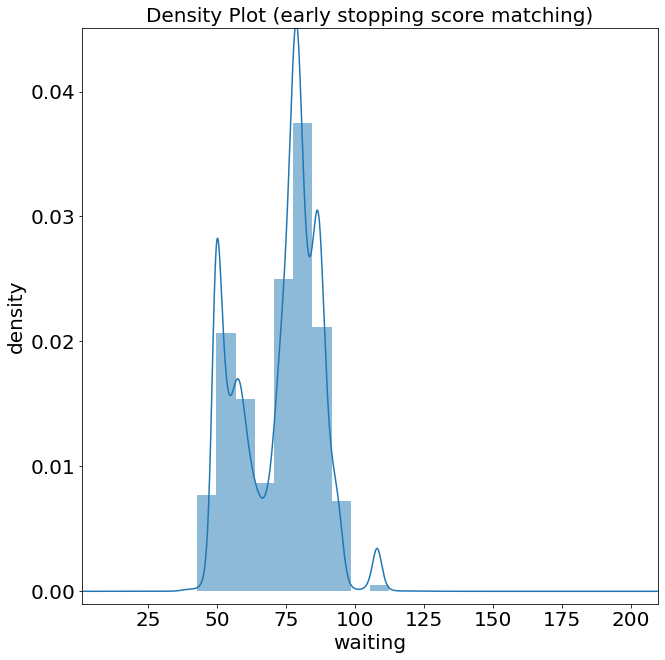

**************************************************
iter number = 900


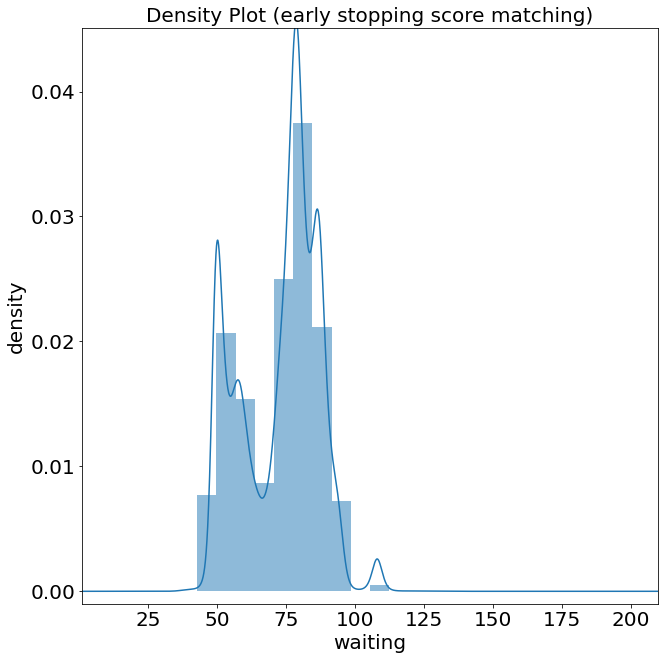

**************************************************
iter number = 800


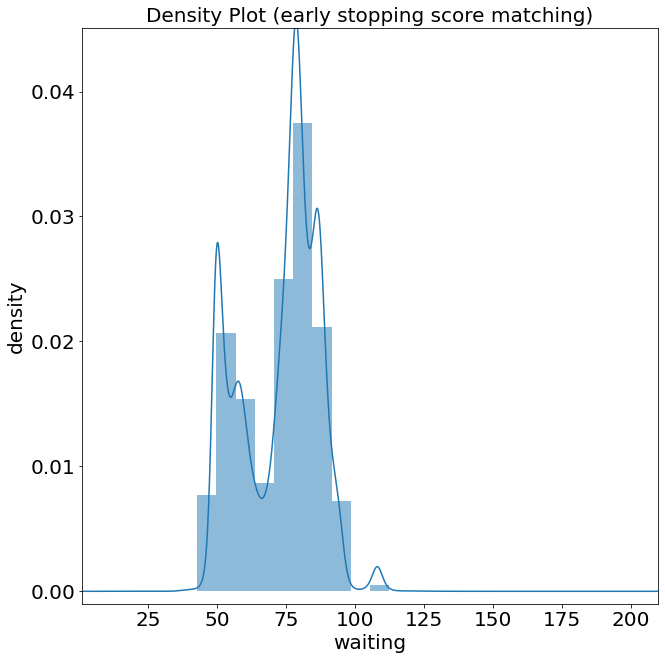

**************************************************
iter number = 700


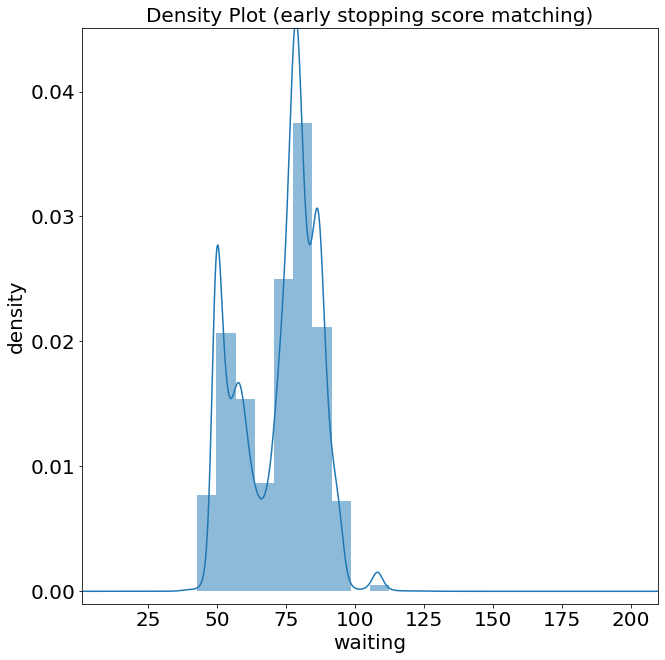

**************************************************
iter number = 600


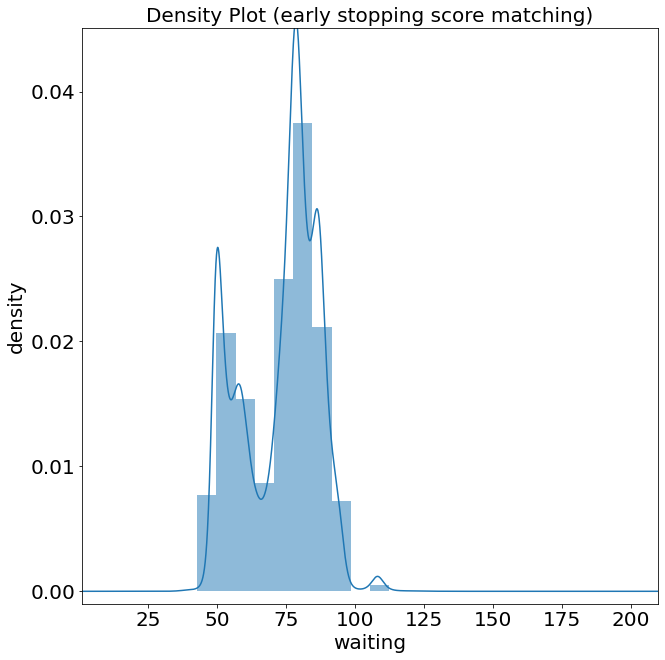

**************************************************
iter number = 500


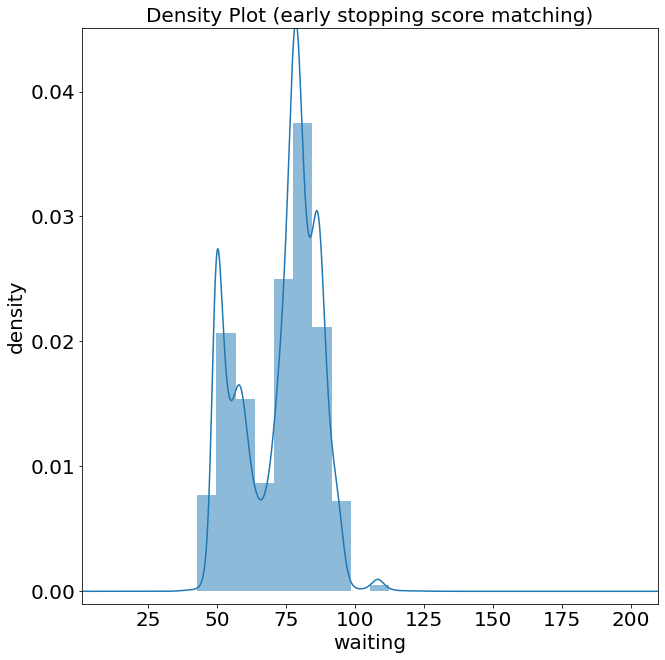

**************************************************
iter number = 400


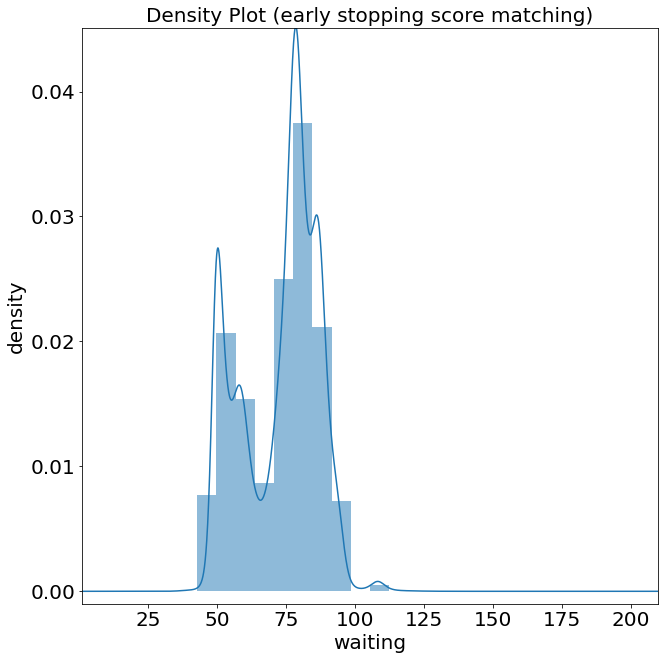

**************************************************
iter number = 300


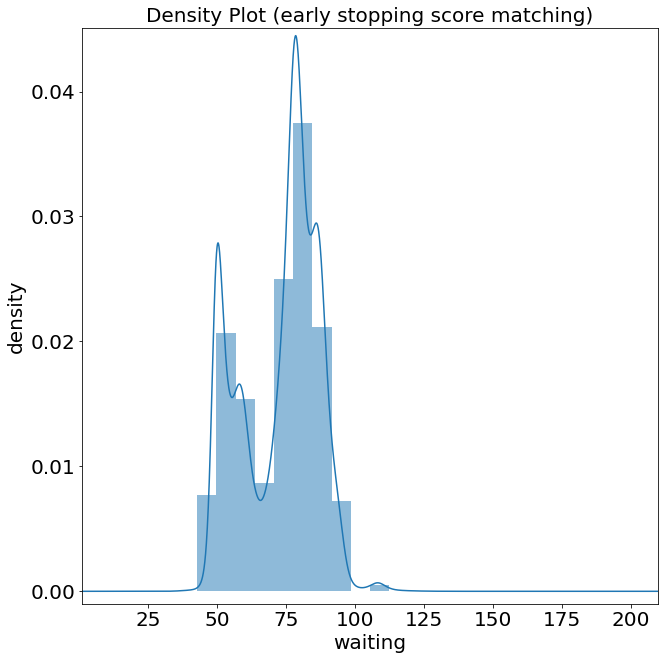

**************************************************
iter number = 200


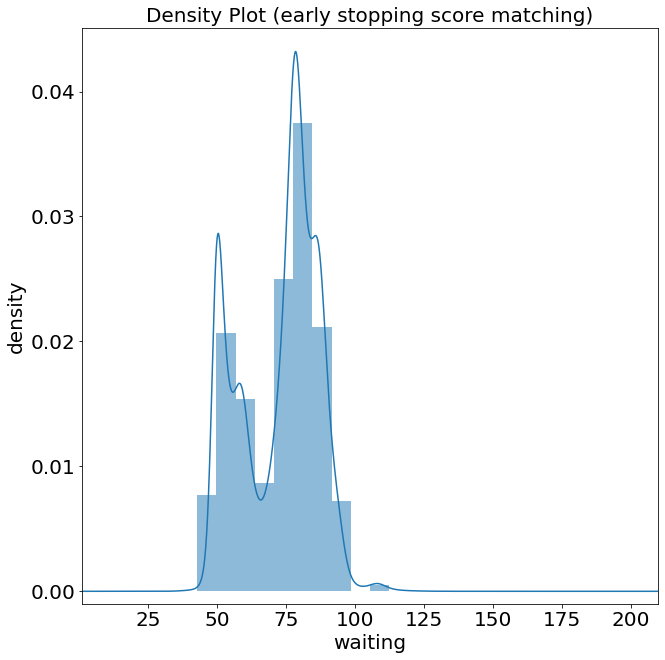

**************************************************
iter number = 150


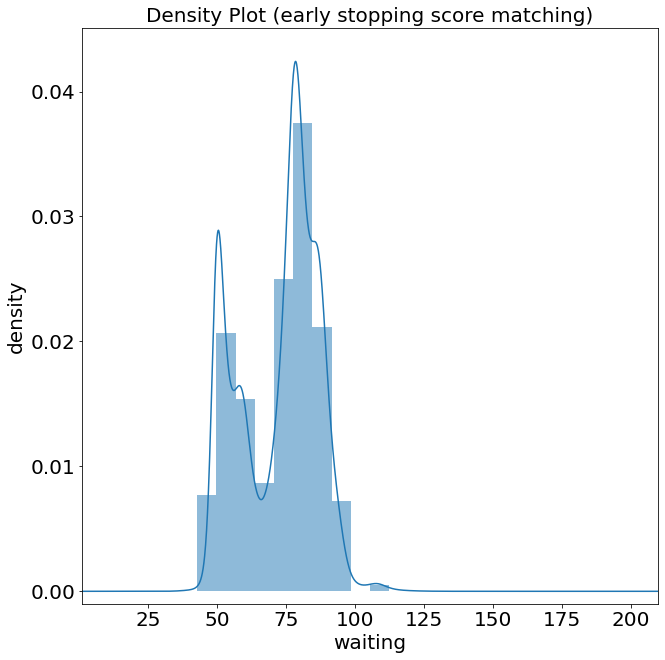

**************************************************
iter number = 100


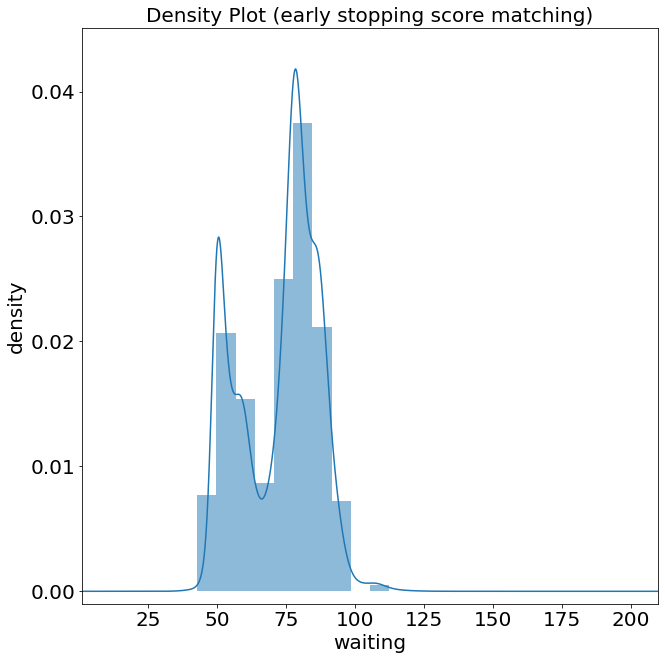

**************************************************
iter number = 90


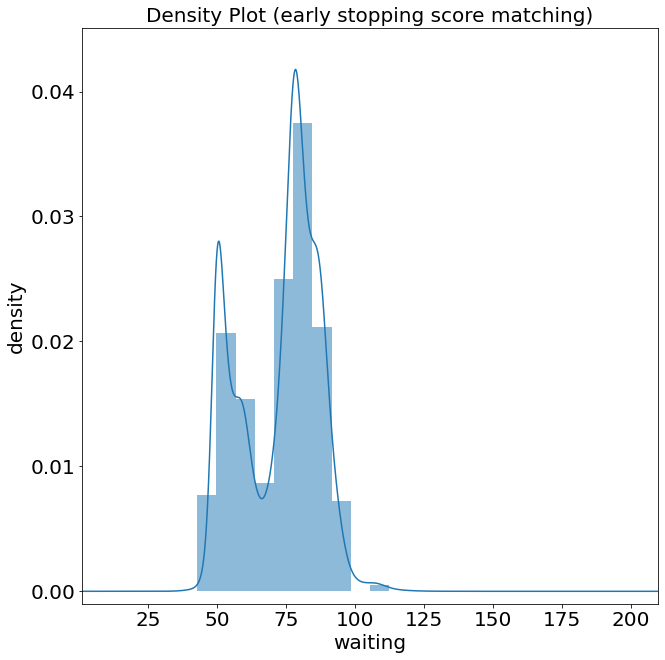

**************************************************
iter number = 80


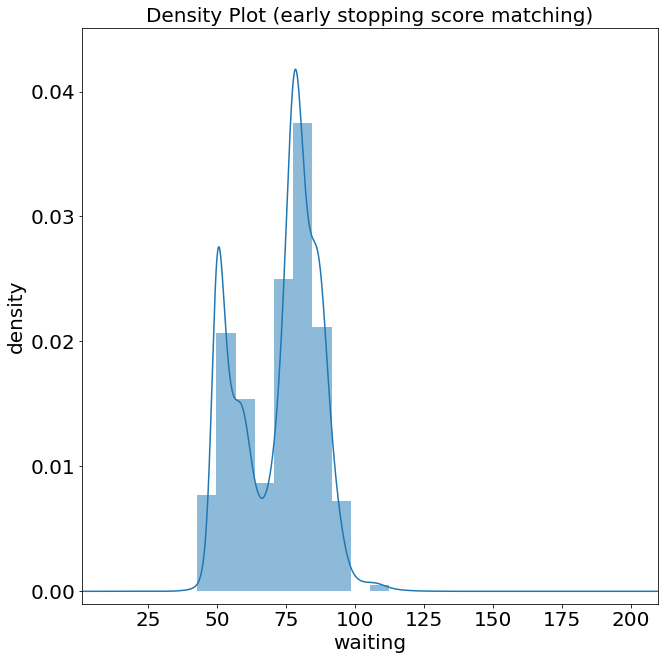

**************************************************
iter number = 70


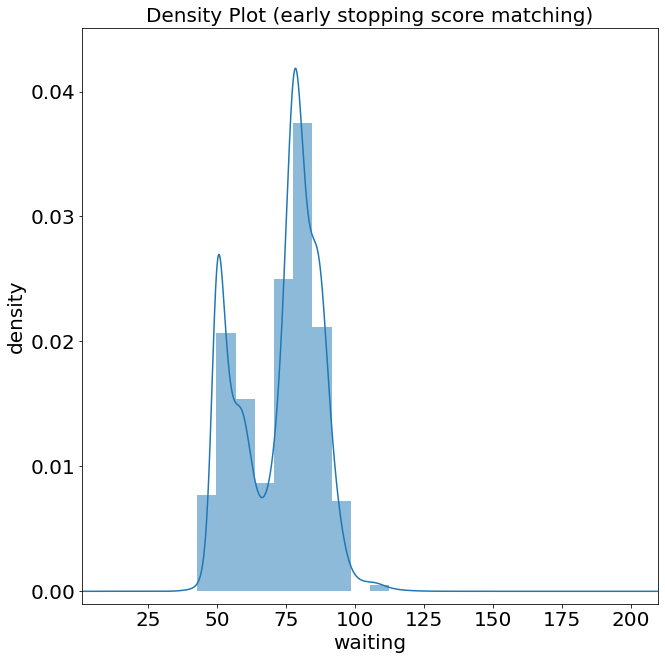

**************************************************
iter number = 60


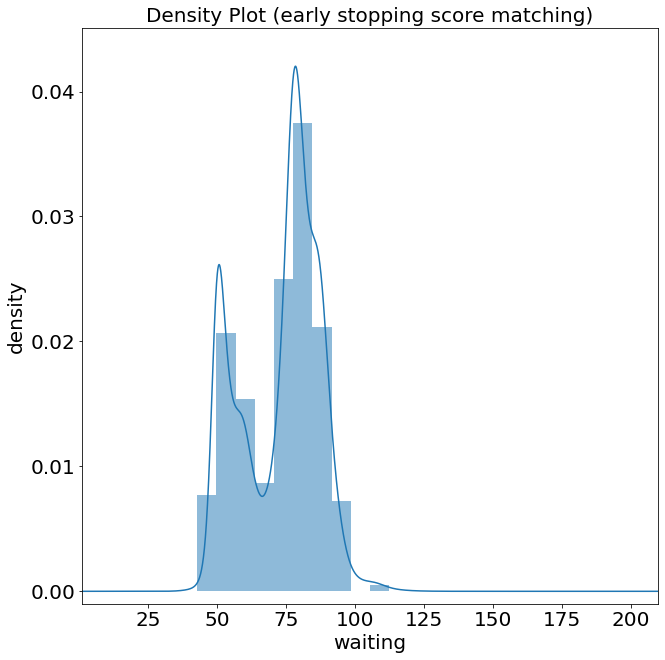

**************************************************
iter number = 50


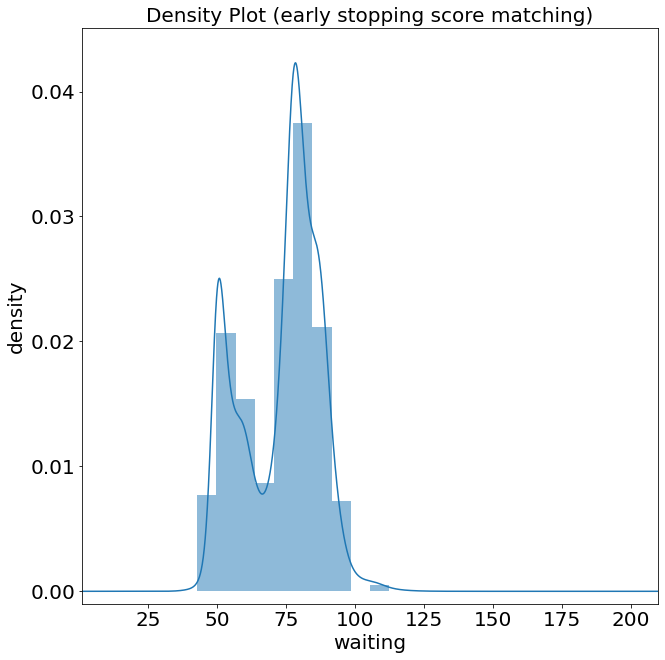

**************************************************
iter number = 40


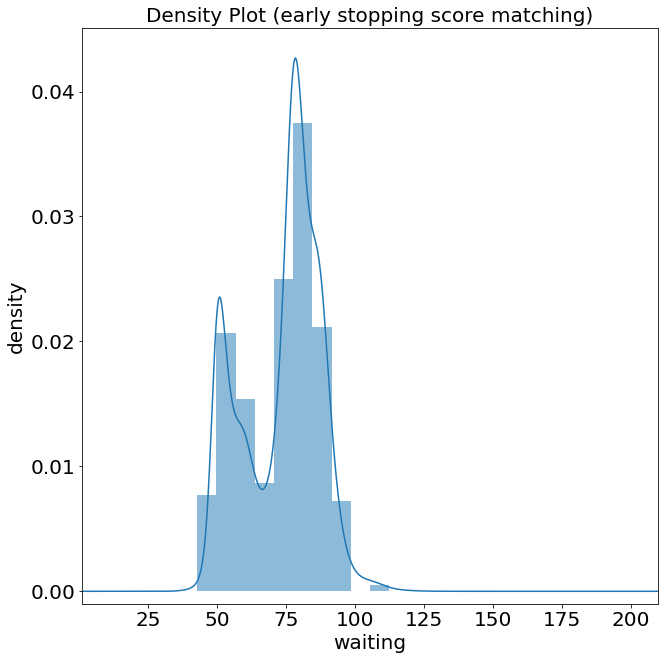

**************************************************
iter number = 30


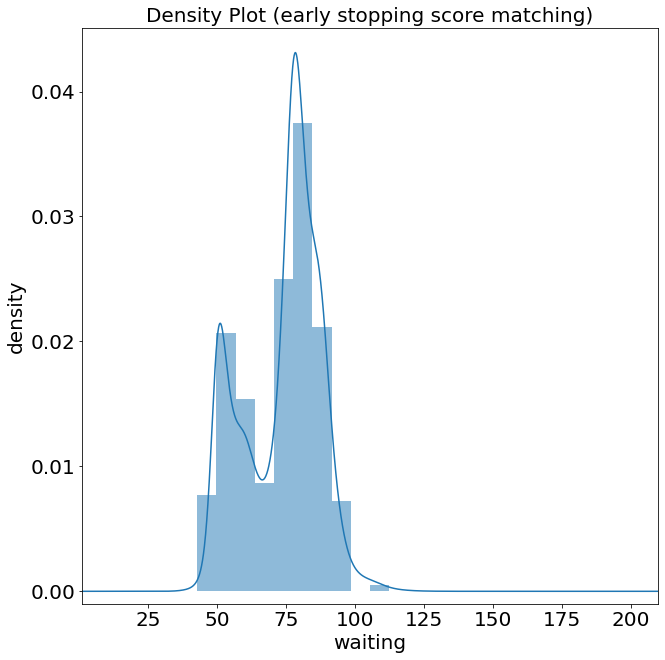

**************************************************
iter number = 20


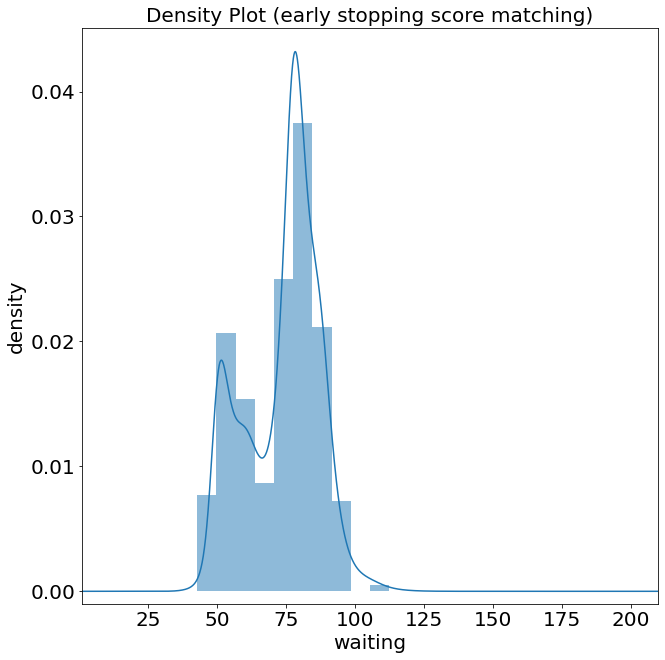

**************************************************
iter number = 10


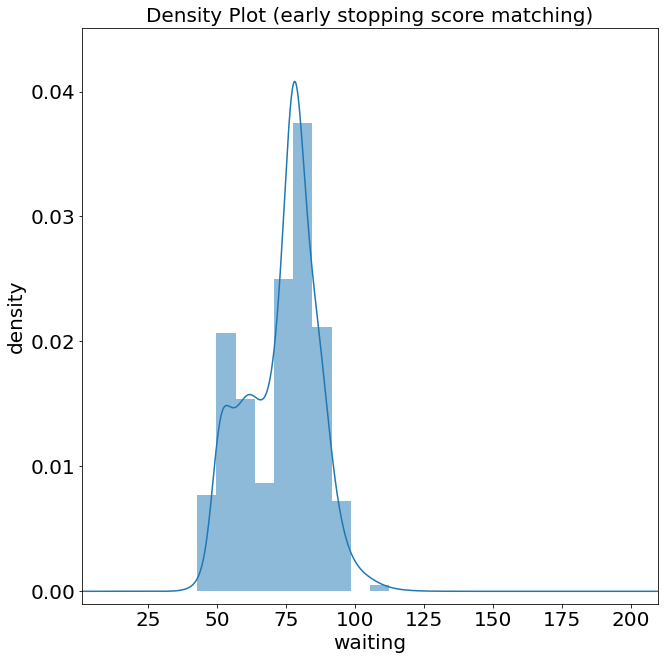

**************************************************
iter number = 5


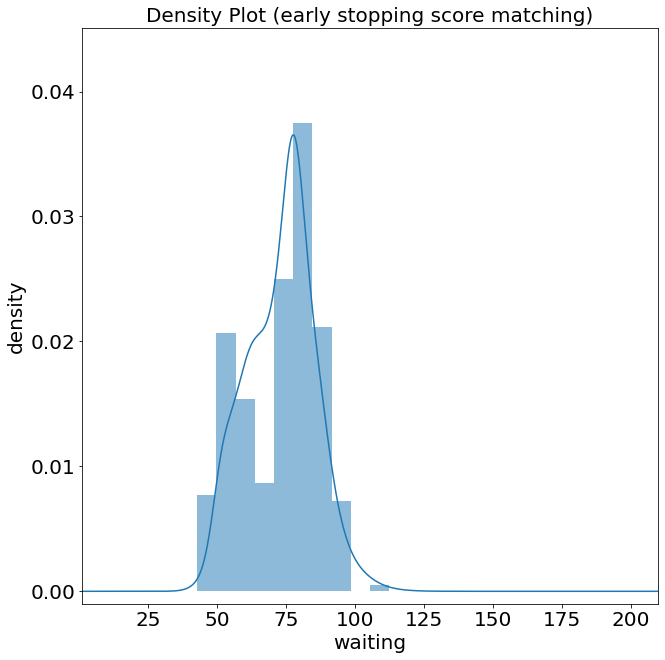

**************************************************
iter number = 1


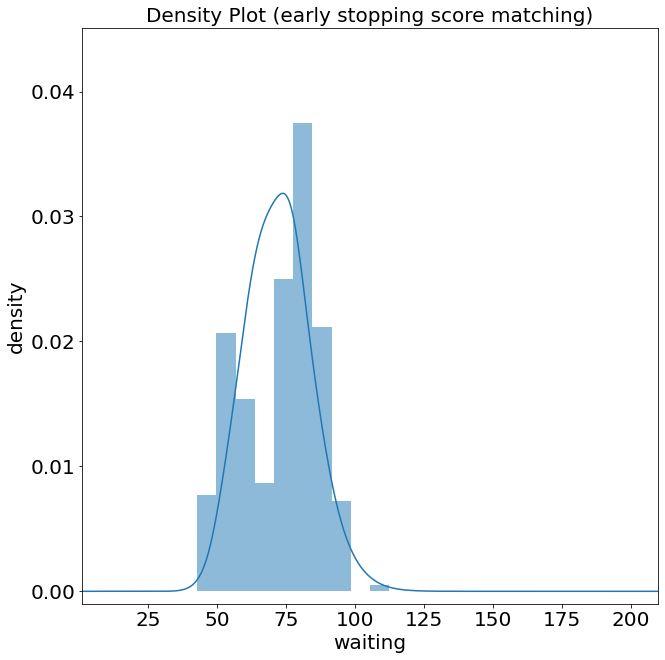

**************************************************
iter number = 0


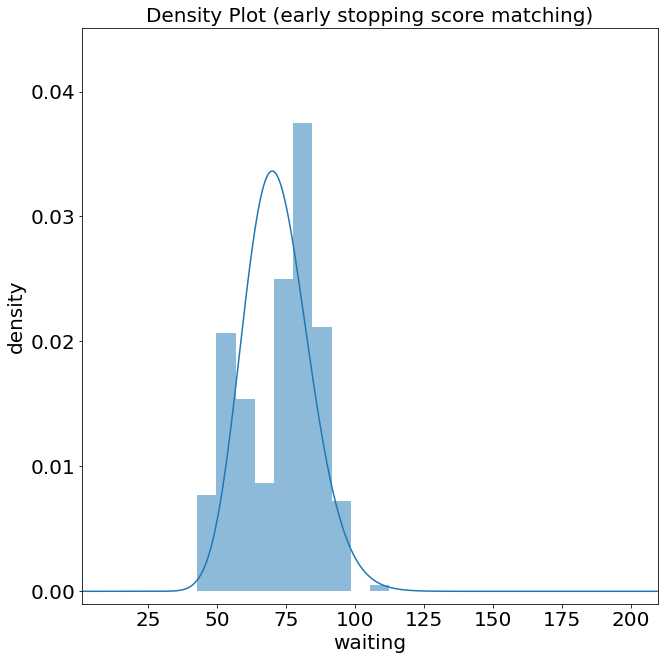

In [12]:
iternum_list = [0, 1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 
                1500, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000, 30000, 40000, 50000, 
                60000, 70000, 80000, 90000, 100000]

for iter_num in iternum_list[::-1]: 
    
    print('*' * 50)
    print(f'iter number = {iter_num}')
    
    coef_smes = sm_es.coef(
        data = waiting, 
        iter_num = iter_num, 
        step_size = 20.)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_es.kernel_function, 
        base_density = base_density, 
        basis_type = 'smbasis', 
        coef = coef_smes, 
        normalizing = True, 
        method = 'early stopping score matching', 
        x_label = 'waiting',
        grid_points = None,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    file_name_coef = f'/iter_num={iter_num}-coef.npy'
    np.save(sm_folder + file_name_coef, coef_smes)

    file_name_den = f'/iter_num={iter_num}-densityvals-newdata.npy'
    np.save(sm_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
iter number = 1500


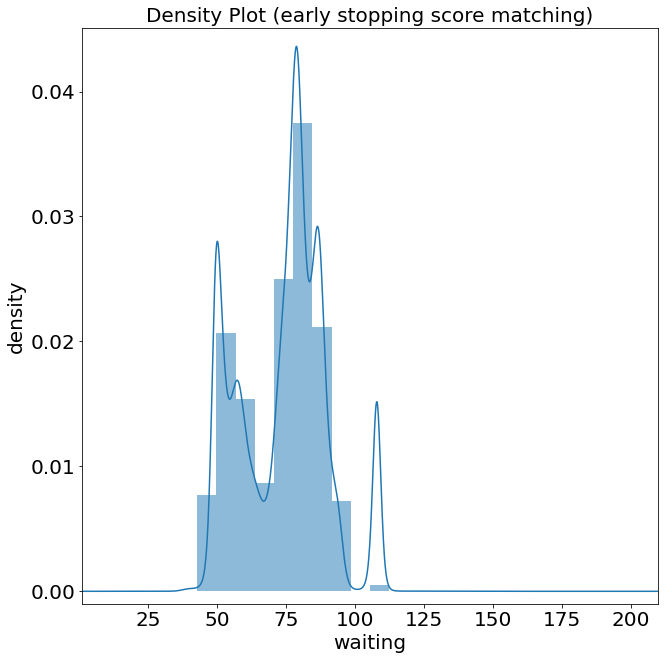

In [9]:
iternum_list = [1500]

for iter_num in iternum_list: 
    
    print('*' * 50)
    print(f'iter number = {iter_num}')
    
    coef_smes = sm_es.coef(
        data = waiting, 
        iter_num = iter_num, 
        step_size = 20.)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting.reshape(-1, 1), 
        kernel_function = sm_es.kernel_function, 
        base_density = base_density, 
        basis_type = 'smbasis', 
        coef = coef_smes, 
        normalizing = True, 
        method = 'early stopping score matching', 
        x_label = 'waiting',
        grid_points = None,
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    file_name_coef = f'/iter_num={iter_num}-coef.npy'
    np.save(sm_folder + file_name_coef, coef_smes)

    file_name_den = f'/iter_num={iter_num}-densityvals-newdata.npy'
    np.save(sm_folder + file_name_den, den_vals['den_vals'])
    

In [ ]:
np.argmin(waiting)

In [ ]:
waiting[53]